# Distributions and Imbalanced Regression

In [1]:
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

import pandas as pd

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense, Dropout, GRU, Conv1D, Flatten, Reshape

import os
import numpy as np
import sys
import tensorflow as tf
import random
import keras
from scipy.interpolate import PchipInterpolator
from statsmodels.stats.stattools import medcouple
import pickle

SEED = 42

def set_seeds(seed=SEED):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    tf.random.set_seed(seed)
    np.random.seed(seed)
    keras.utils.set_random_seed(seed)

def set_global_determinism(seed=SEED):
    set_seeds(seed=seed)

    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
    
    tf.config.threading.set_inter_op_parallelism_threads(1)
    tf.config.threading.set_intra_op_parallelism_threads(1)

# Call the above function with seed value
set_global_determinism(seed=SEED)

In [2]:
# Add the folder to the Python path

os.chdir("../")
# change working directory to project's root path
print(os.getcwd())

folder_path = os.path.abspath("functions/") #INPUT_PATH)#'path_to_your_folder')  # Replace with the actual folder path
sys.path.insert(0, folder_path)

from Predictions import (
    PredictionModel,
    SERA,
    compute_adjusted_boxplot_bounds,
    XGBCustomObjective,
    sera_objective,
    piecewise_linear_phi_2,
    piecewise_linear_phi_np,
    create_relevance_function
)
from indices import get_heatwaves_indices, transform_time_label

c:\Users\marti\Desktop\data\hw_extra


c:\Users\marti\AppData\Local\Programs\Python\Python310\lib\site-packages\tensorflow_addons\utils\tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(


In [3]:
units_hws = {
    "hwn" : "heatwaves",
    "hwf" : "days",
    "hwd" : "days",
    "hwm" : "°K/day",
    "hwa" : "°K",
    "hwi" : "°K",
    "hwmeani": "°K",
    "hwmaxi": "°K",
    "hwmeand": "days"
}

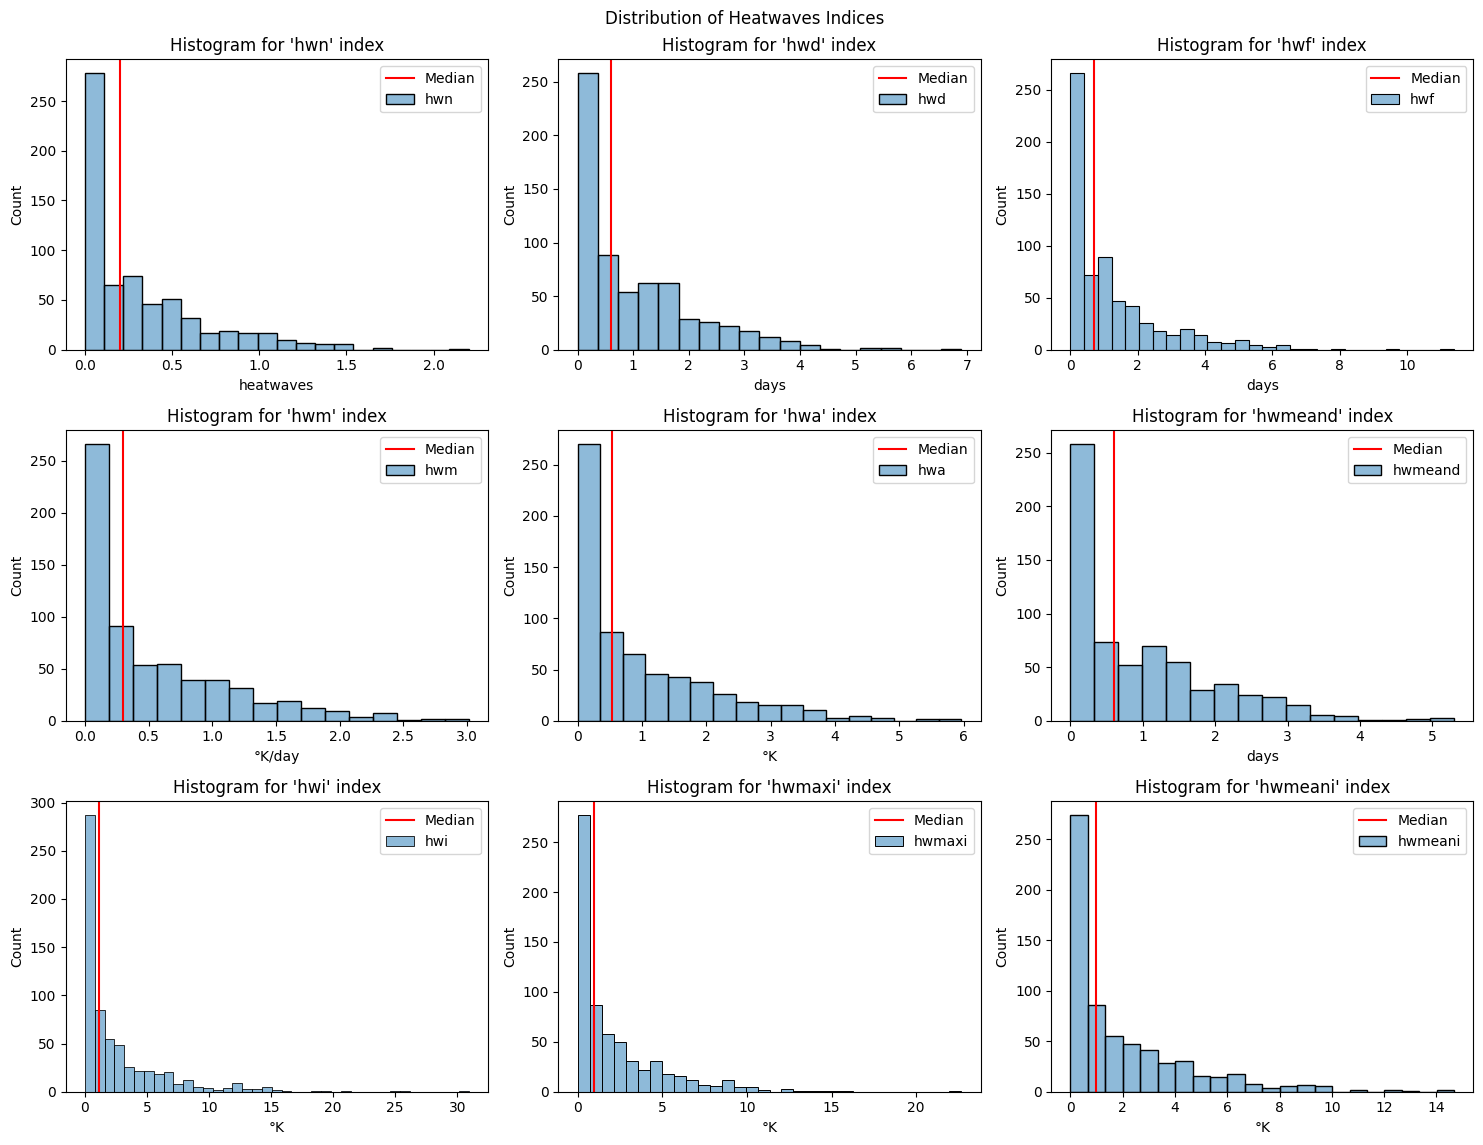

In [4]:
region = "chile"
indices = ["hwn", "hwd", "hwf", "hwm", "hwa", "hwmeand", "hwi", "hwmaxi", "hwmeani"]

hws = pd.read_csv("data/local_data/monthly/hws_chile_new_agg.csv")

hws["time"] = pd.to_datetime(hws["Unnamed: 0"],format='%Y-%m')
hws.set_index('time', inplace=True)
hws.drop(columns="Unnamed: 0", inplace=True)
scaler = StandardScaler()
hws_scaled = hws.copy(deep=True)
hws_scaled[indices] = scaler.fit_transform(hws[indices])
fig, axs = plt.subplots(3, 3, figsize=(15,12))
axs = axs.flatten()
for i, index in enumerate(indices):
    sns.histplot(hws[[index]], ax=axs[i], label=index)
    axs[i].axvline(np.median(hws[[index]]), color='red', label="Median")
    axs[i].set_title(f"Histogram for '{index}' index")
    axs[i].set_xlabel(units_hws[index])
    axs[i].legend()
fig.tight_layout(rect=[0, 0.03, 1, 0.97]) 
fig.suptitle(f"Distribution of Heatwaves Indices")
plt.show()

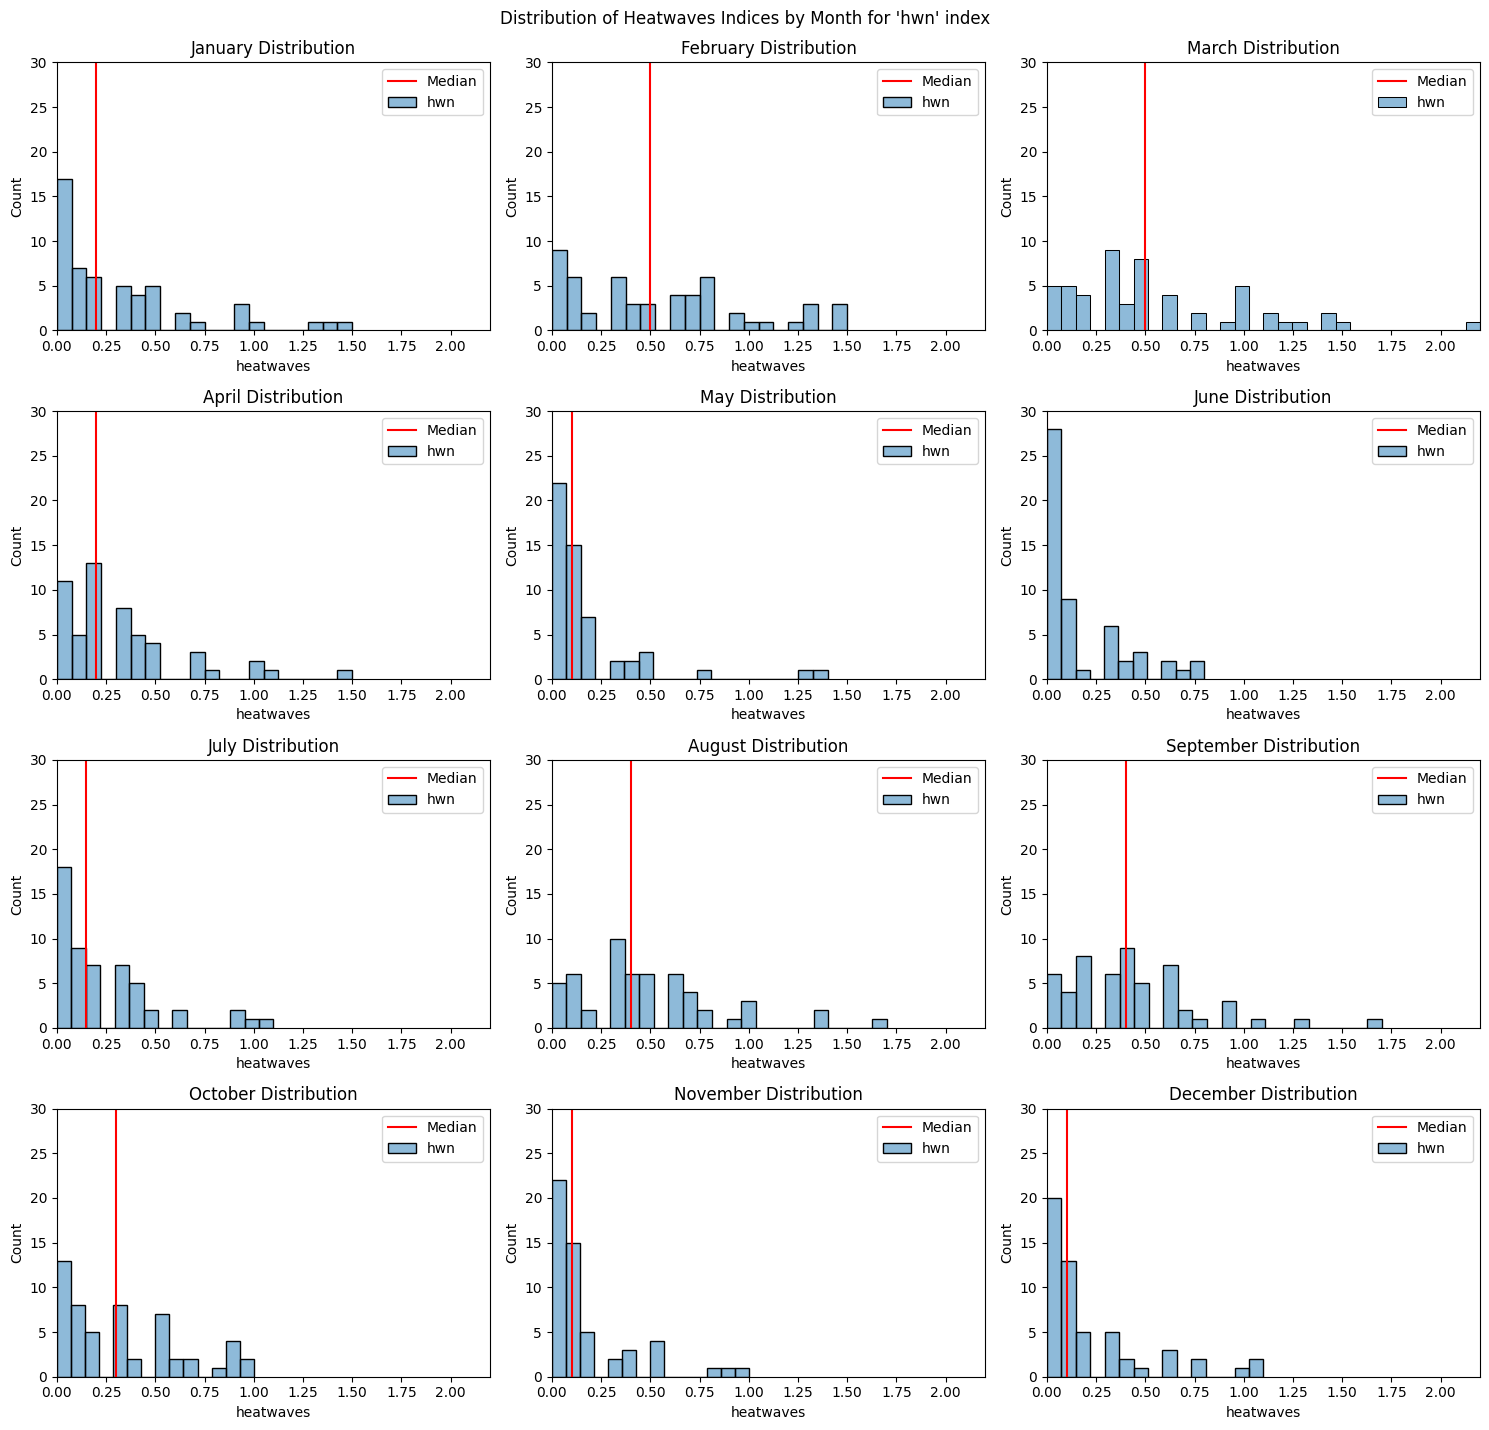

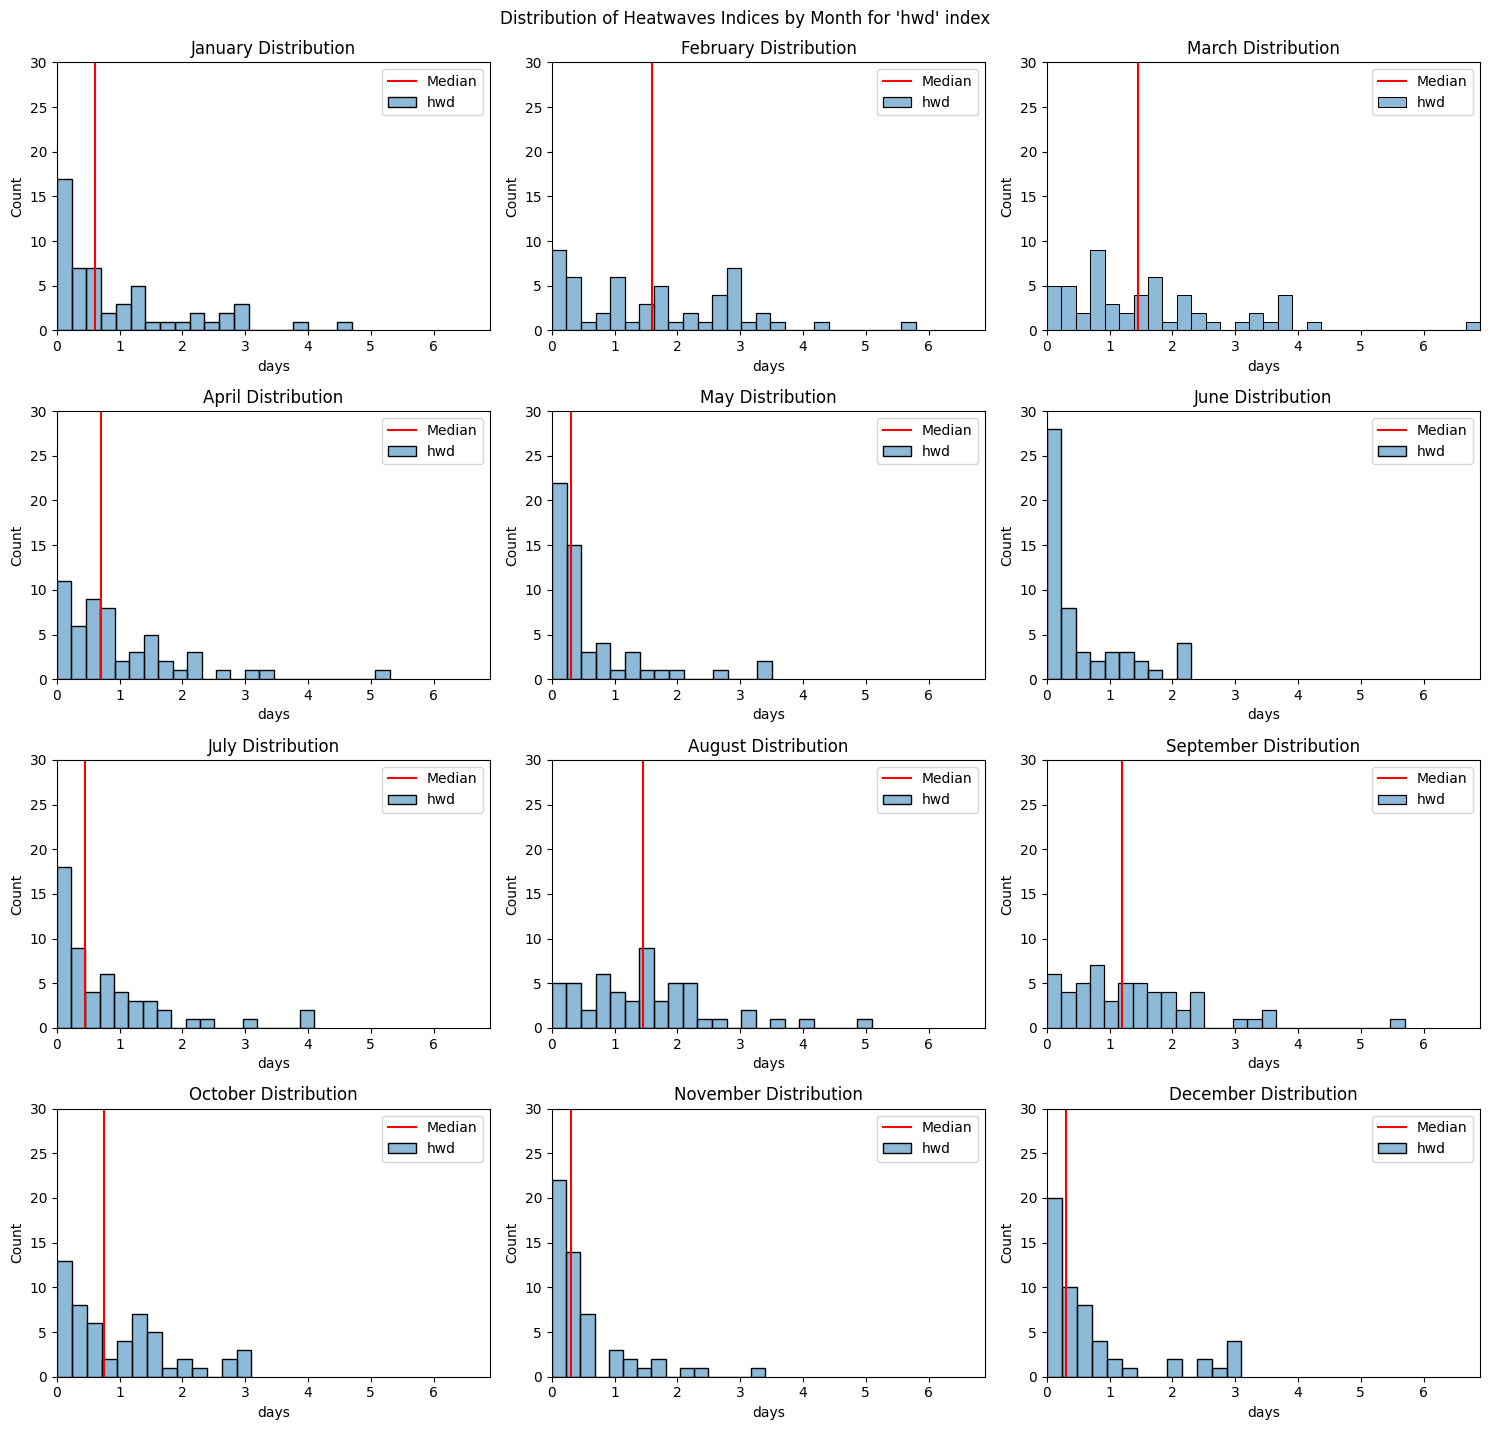

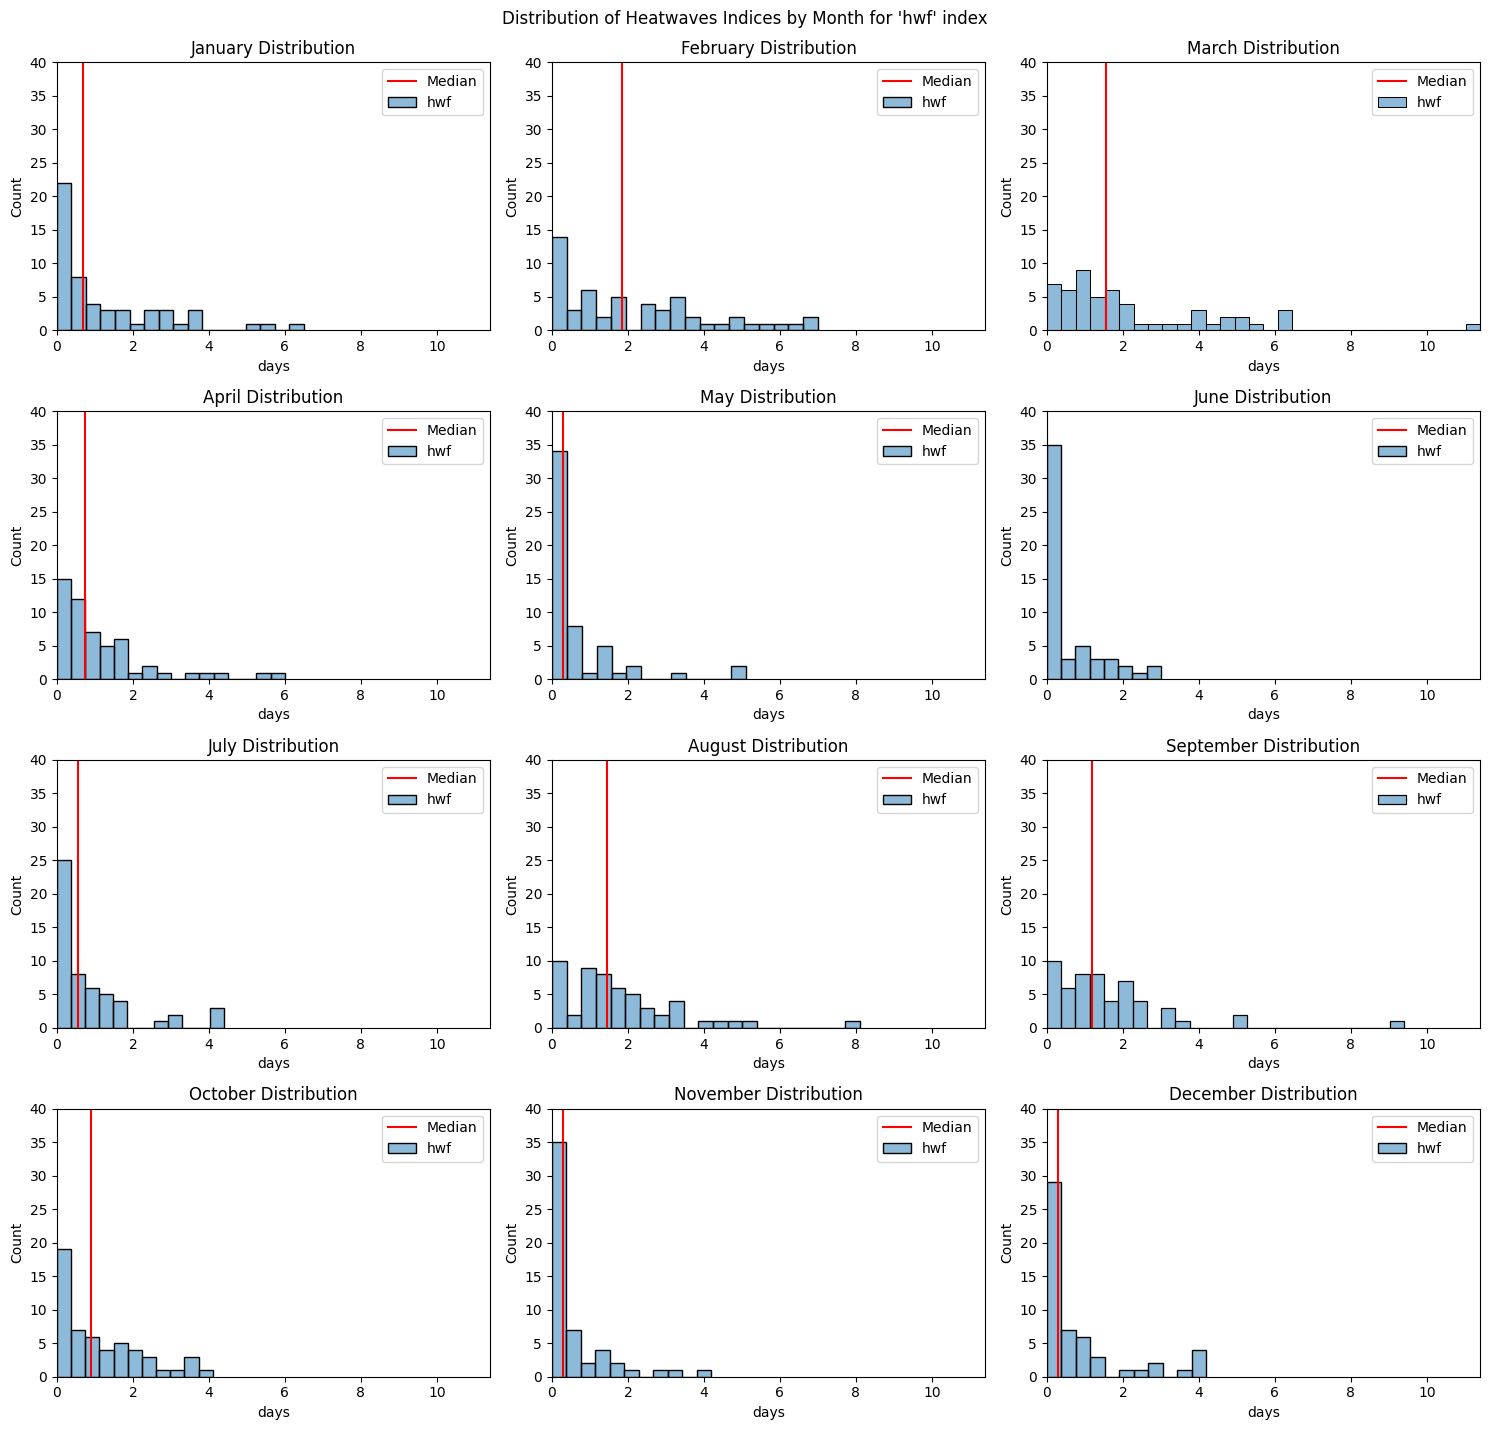

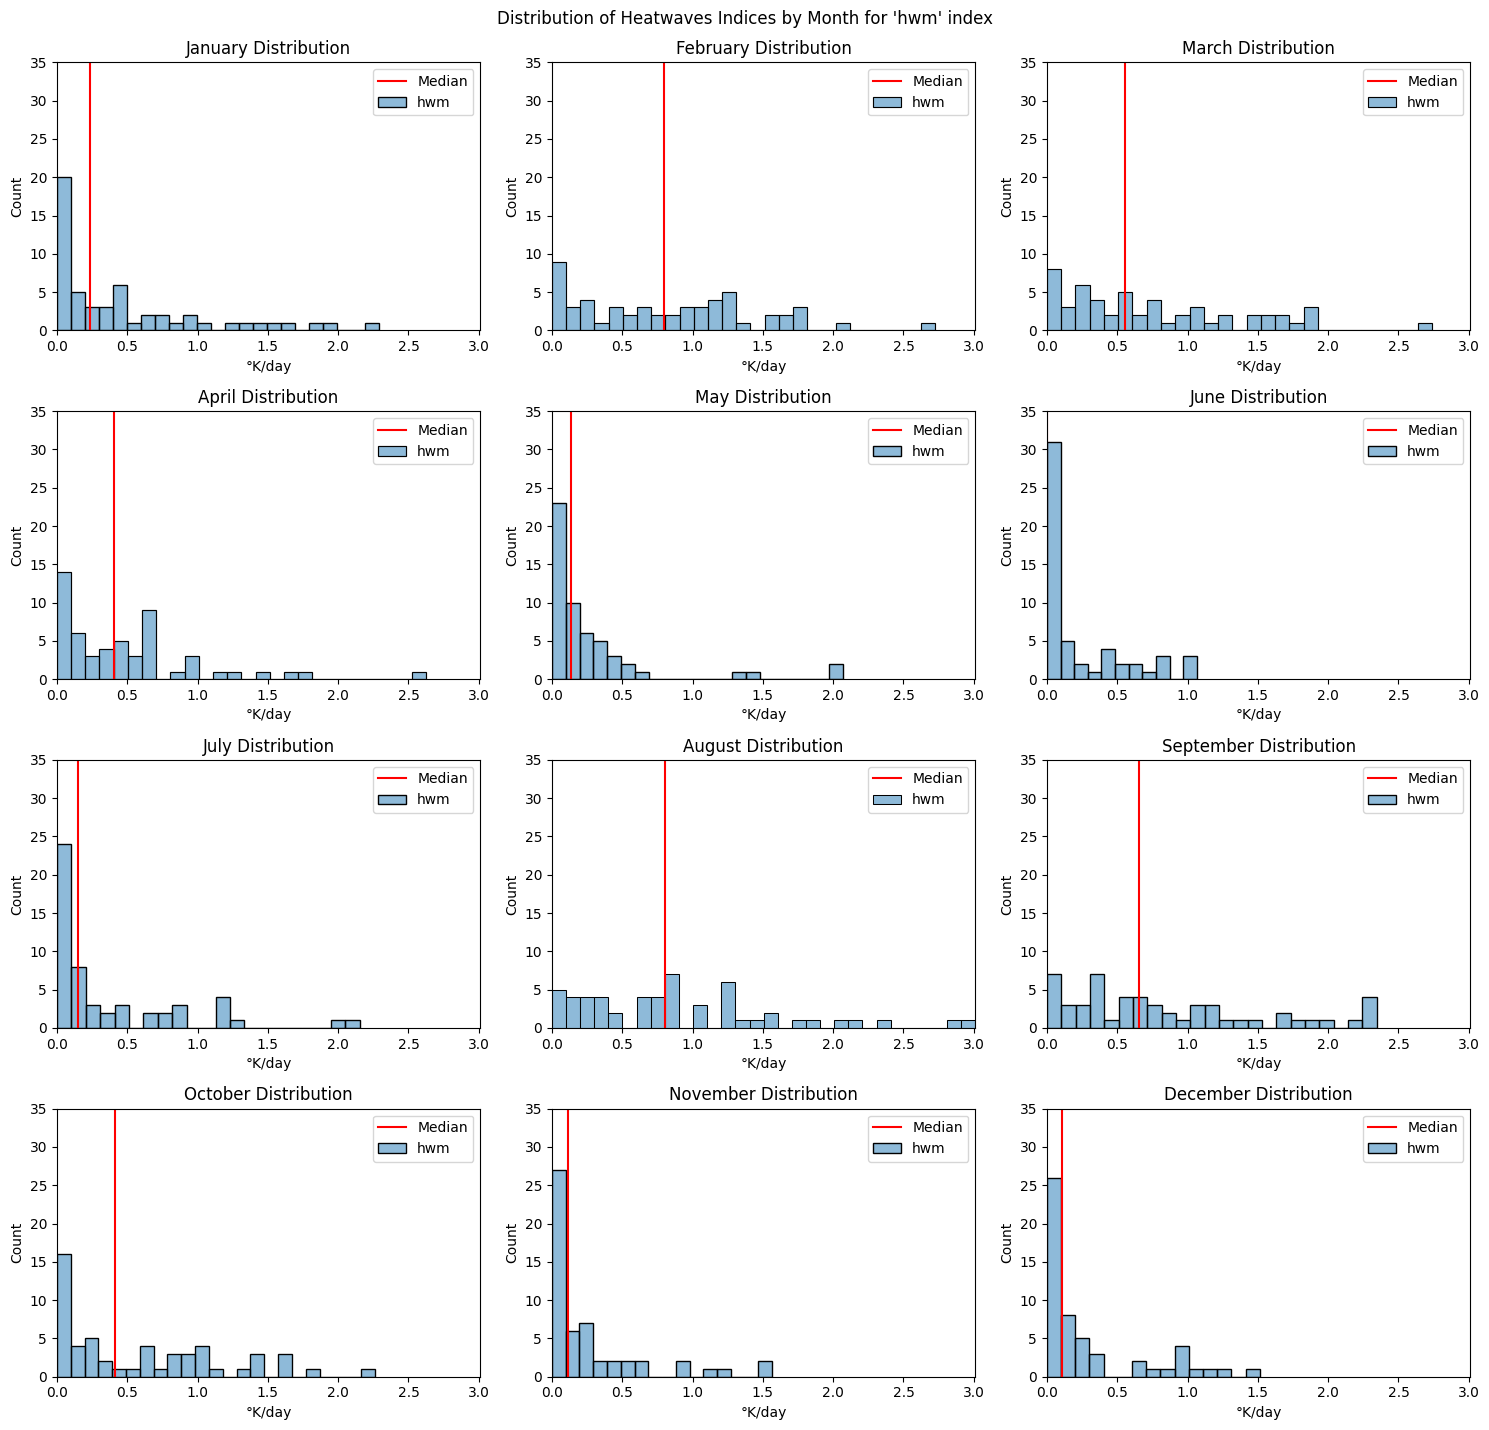

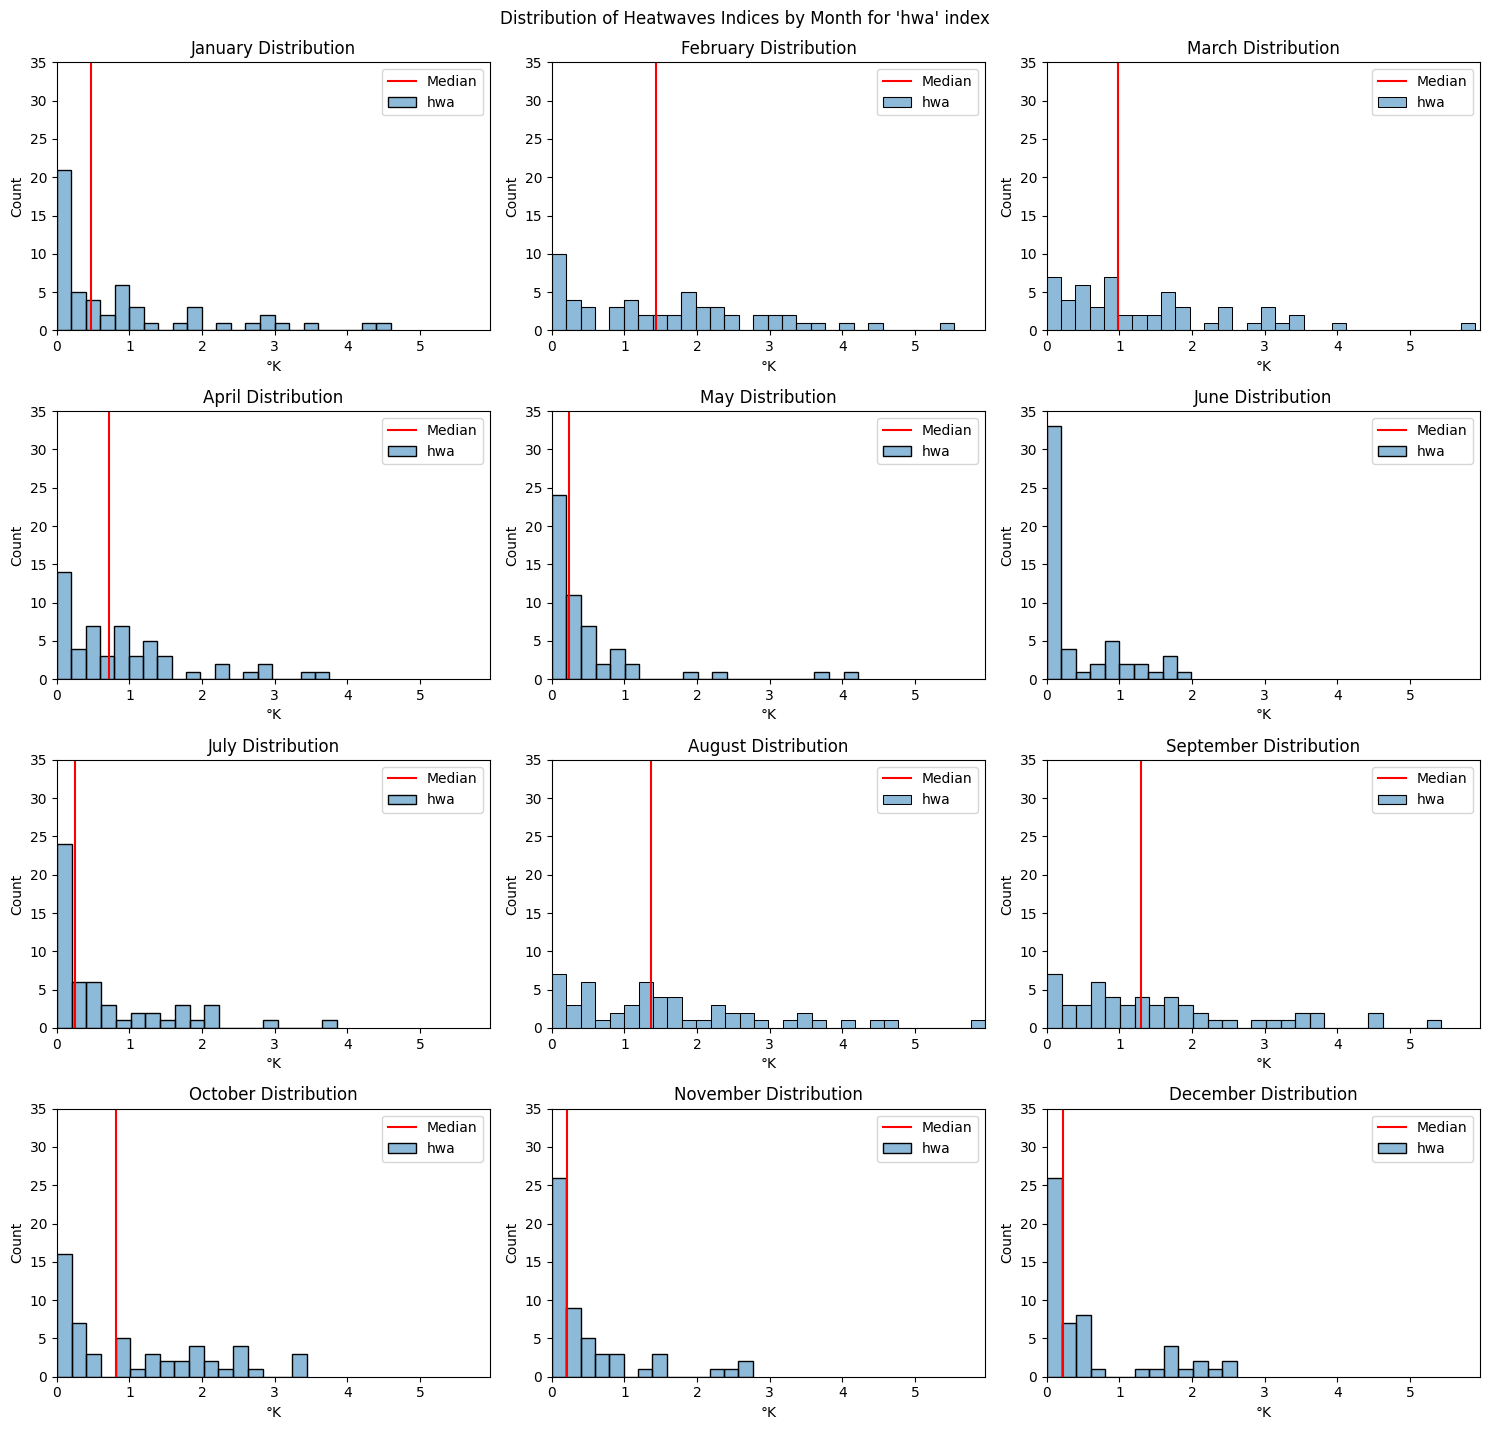

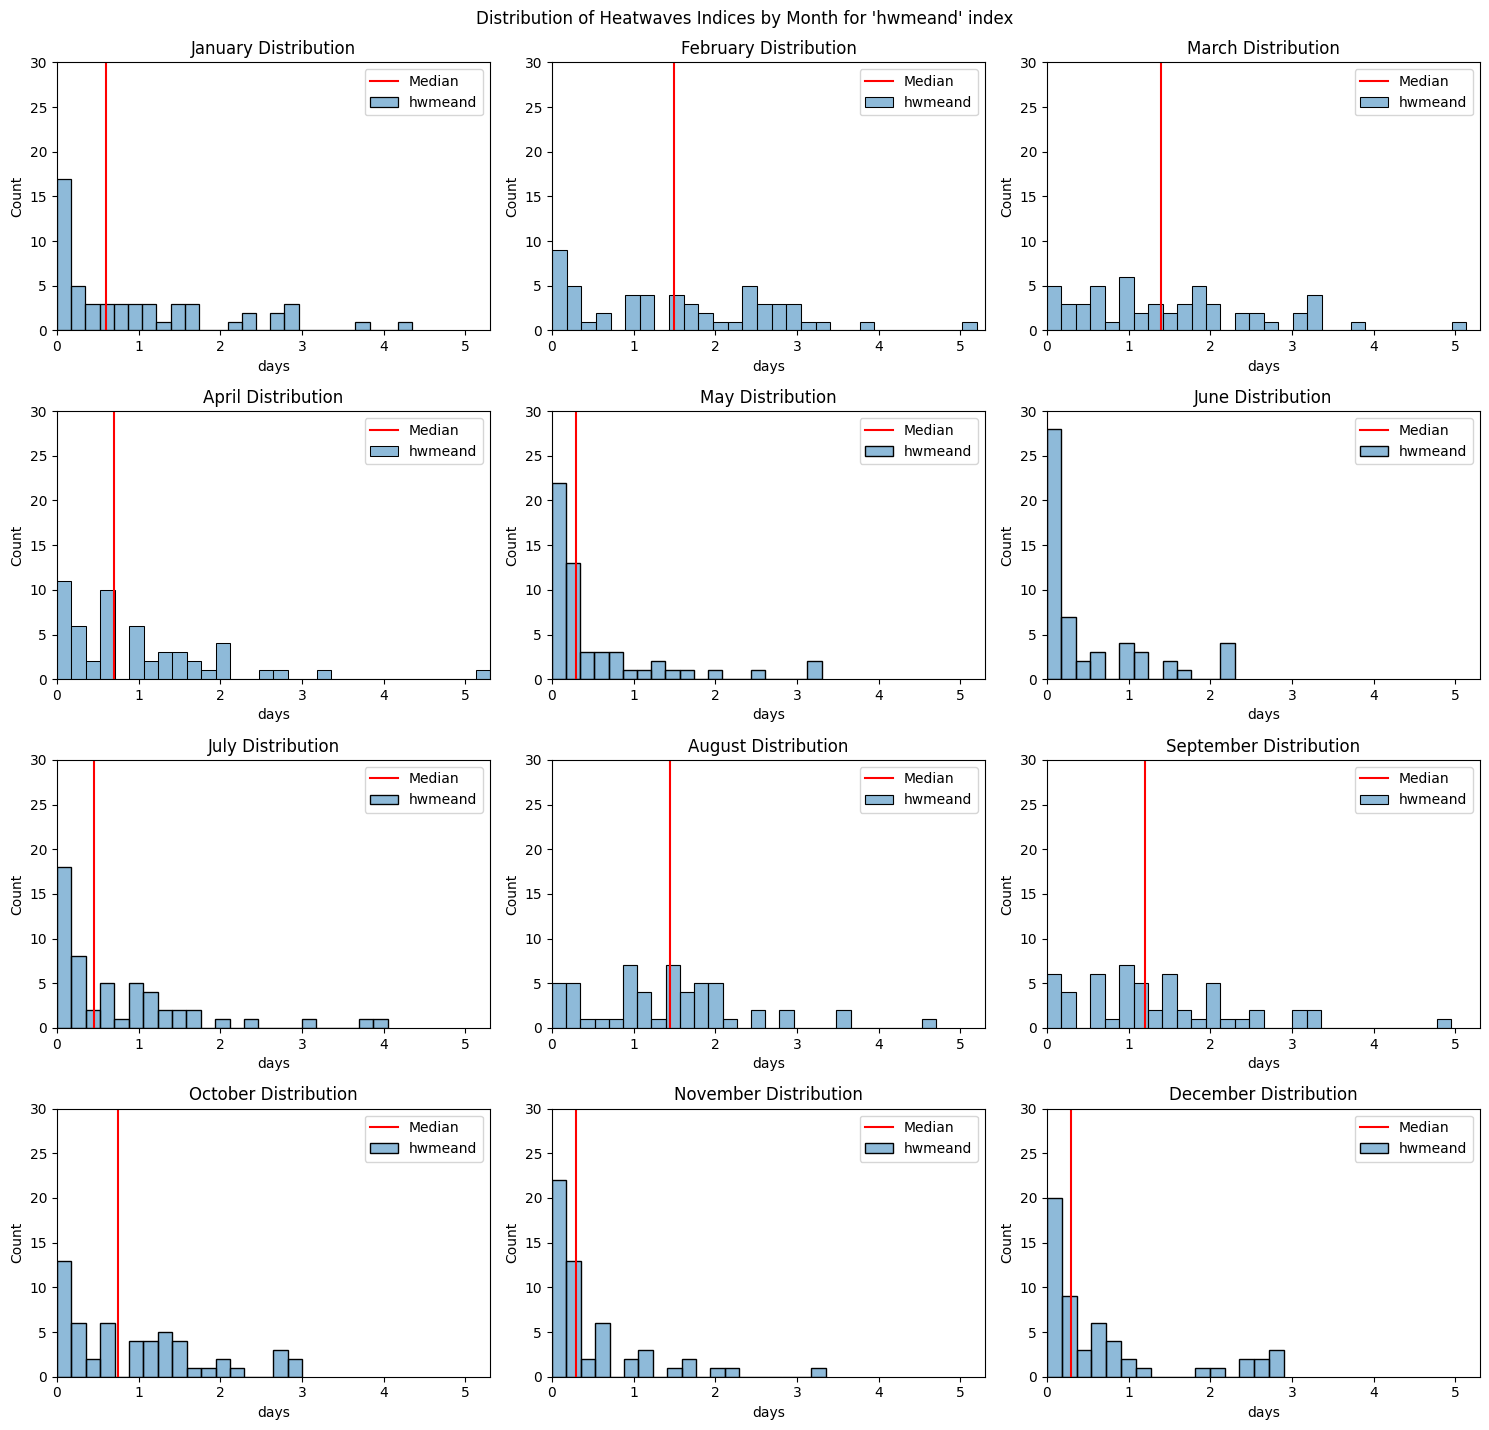

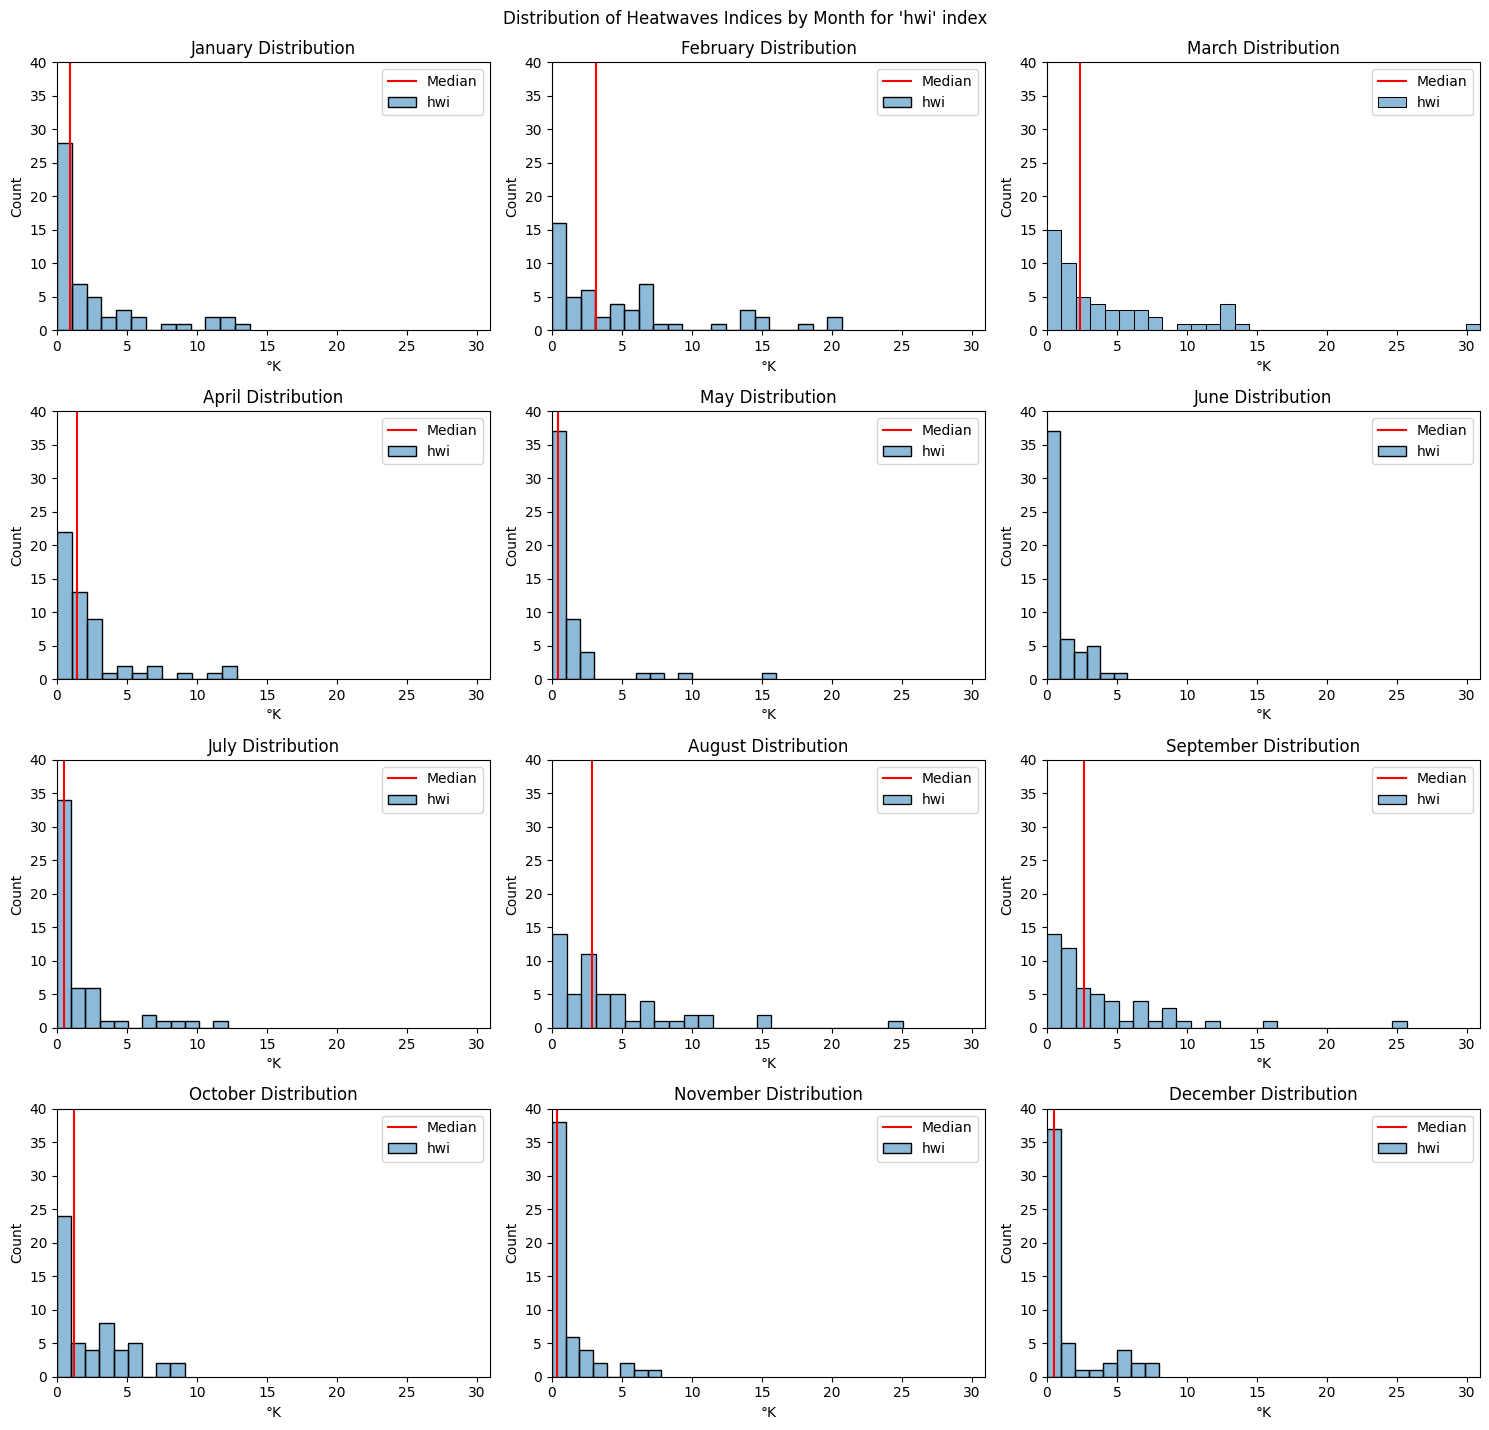

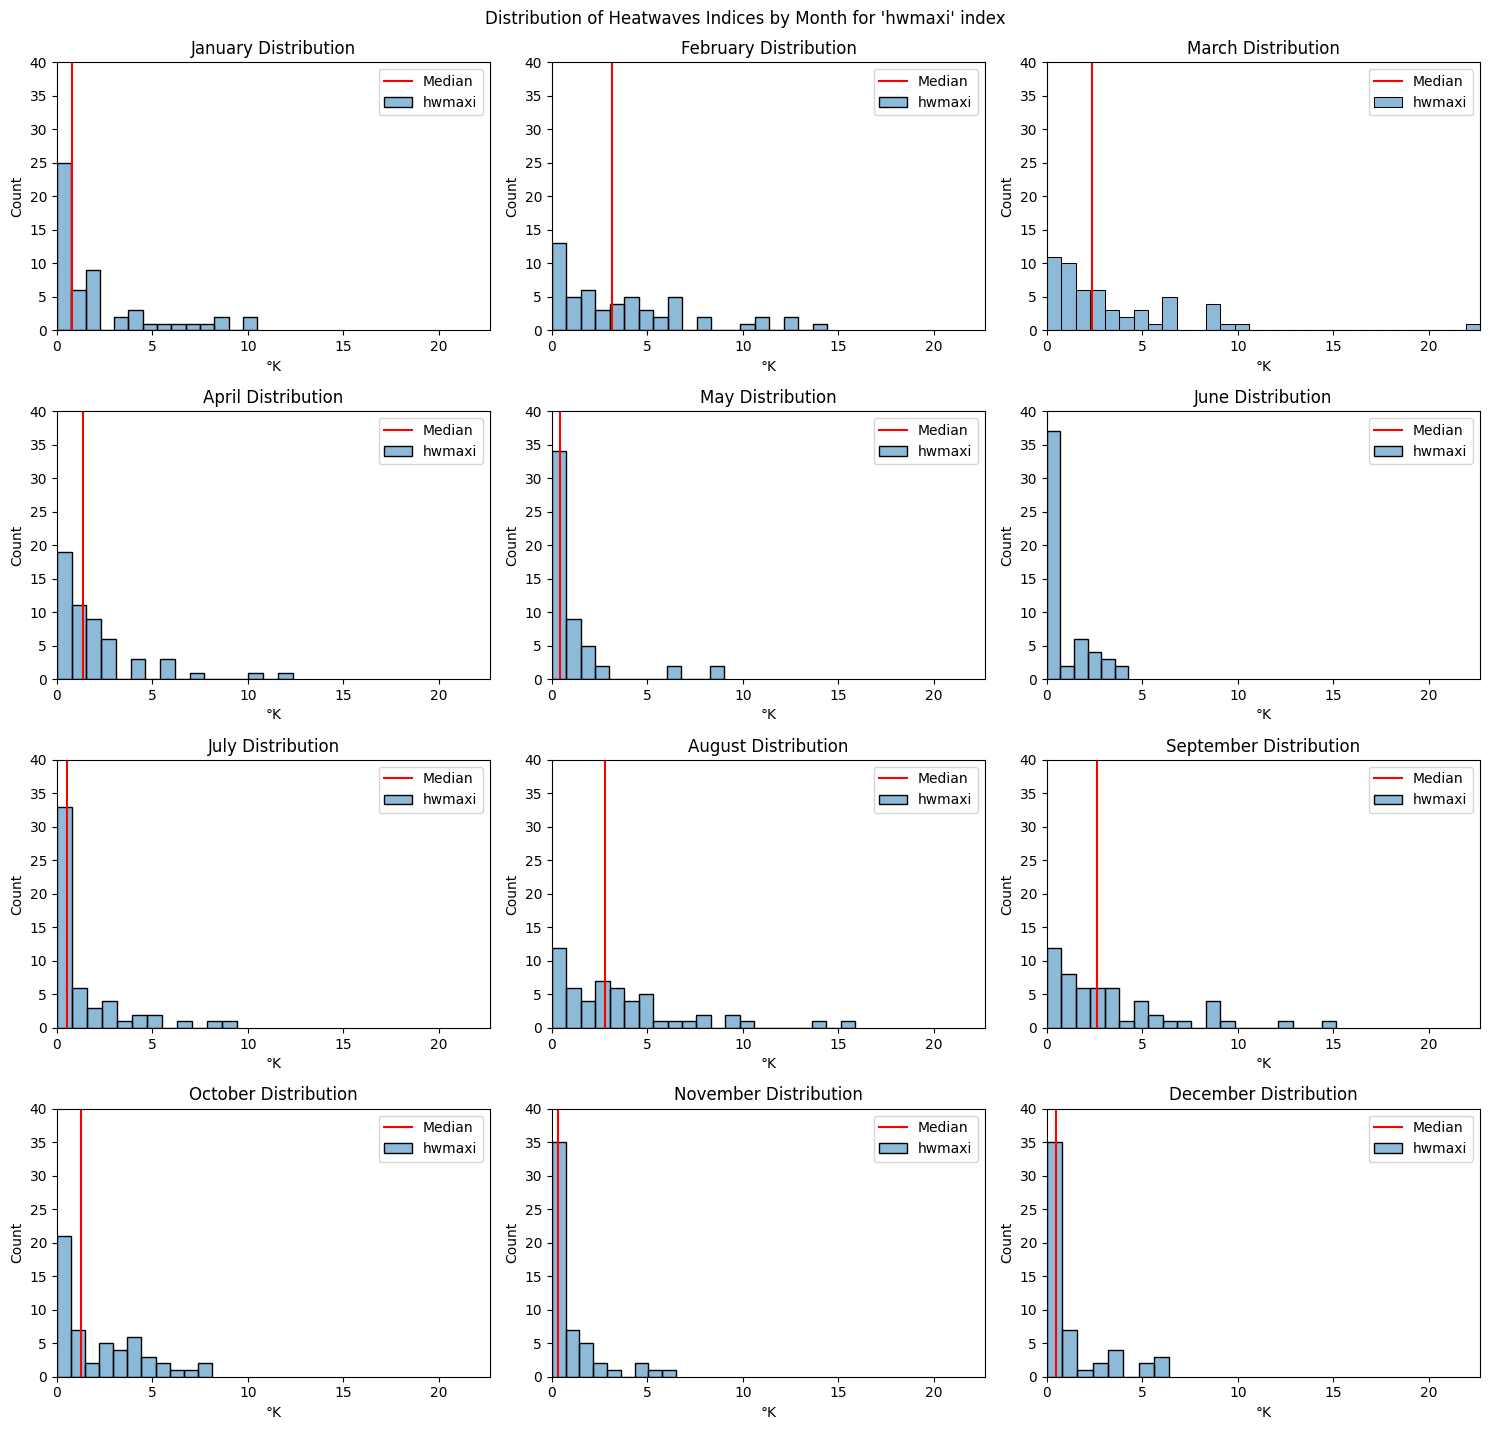

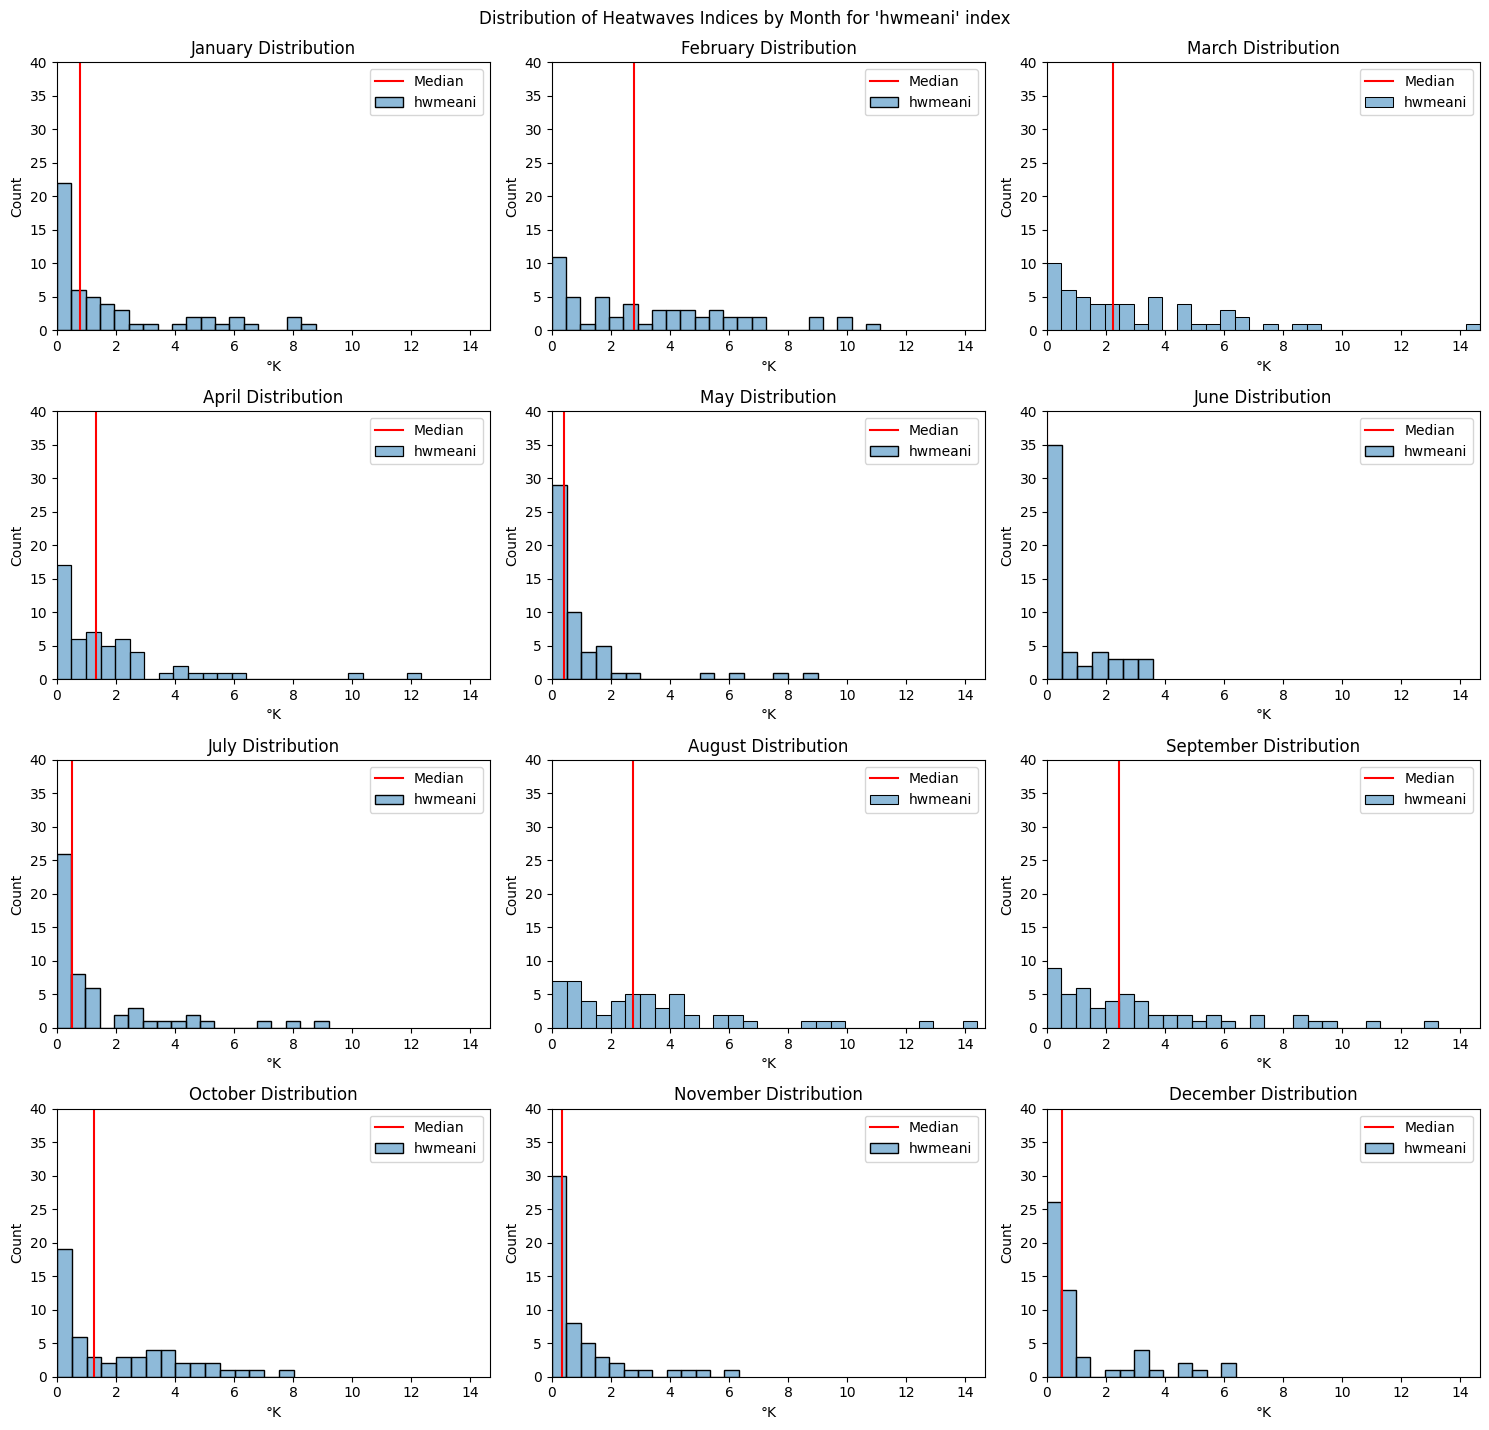

In [5]:
x = np.linspace(-1, 7)
months = {
    1 : "January",
    2 : "February",
    3 : "March",
    4 : "April",
    5 : "May",
    6 : "June",
    7 : "July",
    8 : "August",
    9 : "September",
    10 : "October",
    11 : "November",
    12 : "December"
}
relevance_index = {}
heights = {
    "hwn" : 30,
    "hwd" : 30,
    "hwf" : 40,
    "hwm" : 35,
    "hwa": 35, 
    "hwmeand": 30,
    "hwi": 40,
    "hwmaxi" : 40,
    "hwmeani": 40
}
for k, index in enumerate(indices):
    fig, axs = plt.subplots(4, 3, figsize=(15,15))
    axs = axs.flatten()
    x_min, x_max = hws[index].min(), hws[index].max()
    bin_width = x_max/30
    for i in range(12):
        hws_month = hws[hws.index.month==i+1]
        average = hws_month[index].mean()
        sns.histplot(hws_month[[index]], ax=axs[i], binwidth=bin_width, label=index)
        axs[i].axvline(np.median(hws_month[[index]]), color='red', label="Median")
        axs[i].set_title(f"{months[i+1]} Distribution")
        axs[i].set_xlabel(units_hws[index])
        axs[i].set_xlim(x_min, x_max)
        axs[i].set_ylim(0, heights[index])
        axs[i].legend()
    fig.tight_layout(rect=[0, 0.03, 1, 0.97]) 
    fig.suptitle(f"Distribution of Heatwaves Indices by Month for '{index}' index")
    fig.savefig(f"{index}_distribution_seasonly.png", format="png")
    plt.show()


In [6]:
with open("data/03_primary/drivers/era5_dict.pickle", 'rb') as handle:
    era5_v2 = pickle.load(handle)
era5_df = pd.concat((era5_v2["ERA5"],hws),axis=1)
era5_df = era5_df[era5_df.index.year > 1970]
era5_df

,nino12,nino34,anom_wind_cl_raco,anom_wind_cl_puelche,anom_wind_pressure,anom_ta_cl,anom_pdo,anom_psl_sam_40,anom_psl_sam_65,anom_dmi_east,...,adv_chile,hwn,hwf,hwd,hwm,hwa,hwmeand,hwi,hwmaxi,hwmeani
time,,,,,,,,,,,,,,,,,,,,,
1971-01-01,-1.323449,-1.479654,0.004568,1.626114,-155.360306,-2.929806,-0.074776,-112.387703,341.377930,-0.536907,...,4.134146,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
1971-02-01,-1.141428,-1.604307,-0.288501,0.221068,-98.484497,-0.503788,-0.037966,57.690361,51.769032,-0.933078,...,0.214954,0.2,0.7,0.7,0.447148,0.807169,0.7,1.508644,1.508644,1.508644
1971-03-01,-1.170822,-1.821136,-0.237063,0.329253,-77.386848,-1.261046,-0.144552,6.743707,-146.034164,-0.957672,...,0.069712,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
1971-04-01,-0.556328,-1.182318,-0.485039,-0.753484,198.601791,-1.349036,-0.087349,-70.511070,233.869843,-0.813266,...,-1.091872,0.2,0.6,0.6,0.637038,0.982249,0.6,1.911113,1.911113,1.911113
1971-05-01,-1.159086,-1.029230,-0.084317,0.738629,185.134171,0.668153,-0.267097,-178.369583,701.905396,-0.772716,...,-0.240826,0.1,0.3,0.3,0.555671,0.901254,0.3,1.667013,1.667013,1.667013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-01,-0.107980,0.082571,-0.306670,-1.884179,452.930206,-1.053086,1.098336,-203.018234,536.929138,0.361525,...,-1.233973,0.4,1.3,1.3,0.759857,1.294393,1.3,2.501609,2.501609,2.501609
2024-09-01,-0.487674,-0.298912,0.694752,3.229236,-654.225525,-0.559750,1.172889,281.185516,-122.286896,0.537031,...,2.535206,0.2,0.6,0.6,0.367076,0.617588,0.6,1.101228,1.101228,1.101228
2024-10-01,-0.374066,-0.440446,-0.493092,-1.423323,114.399475,2.943502,1.171113,-6.615347,21.412451,0.930432,...,4.639970,0.4,1.2,0.9,0.853280,1.349775,0.9,3.552305,2.792164,2.559840


## 9 labels, 1971-2018 training, average paper bounds

In [7]:
def average_bounds(list_bounds):
    result_bounds = []
    result_bounds.append(np.min([b[0] for b in list_bounds]))
    result_bounds.append(np.mean([b[1] for b in list_bounds]))
    result_bounds.append(np.mean([b[2] for b in list_bounds]))
    result_bounds.append(np.max([b[3] for b in list_bounds]))
    print("Result bounds", result_bounds)
    return result_bounds

In [8]:
hws_scaled_training = hws_scaled[hws_scaled.index.year <= 2018]
hws_scaled_training

,hwn,hwf,hwd,hwm,hwa,hwmeand,hwi,hwmaxi,hwmeani
time,,,,,,,,,
1971-01-01,-0.902007,-0.809866,-0.921411,-0.874185,-0.856753,-0.953406,-0.679410,-0.754036,-0.794819
1971-02-01,-0.348503,-0.352786,-0.282047,-0.129874,-0.142431,-0.264978,-0.288110,-0.231514,-0.196311
1971-03-01,-0.902007,-0.809866,-0.921411,-0.874185,-0.856753,-0.953406,-0.679410,-0.754036,-0.794819
1971-04-01,-0.348503,-0.418083,-0.373385,0.186212,0.012510,-0.363324,-0.183720,-0.092118,-0.036643
1971-05-01,-0.625255,-0.613975,-0.647398,0.050771,-0.059168,-0.658365,-0.247033,-0.176662,-0.133483
...,...,...,...,...,...,...,...,...,...
2018-08-01,0.758506,0.365483,0.448654,1.148896,1.176166,0.521797,0.459181,0.542758,0.651668
2018-09-01,0.758506,0.561374,0.448654,0.375001,0.604457,0.374277,0.464417,0.271803,0.195336
2018-10-01,-0.348503,-0.418083,-0.373385,-0.456658,-0.336863,-0.363324,-0.484234,-0.493408,-0.496290


Index hwn paper bounds: (-1.449139768962398, -0.34850263556114713, 6.1239300325912955, 5.1865392233511916)


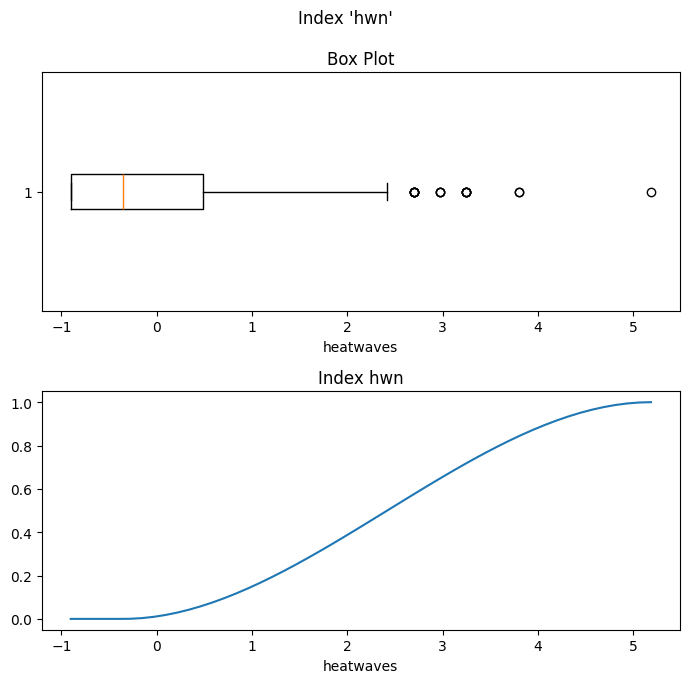

In [9]:
indices_of_interest = ["hwn"]
fig, axs = plt.subplots(2, len(indices_of_interest), figsize=(7,7))
for i, index in enumerate(indices_of_interest):
    hws_index = hws_scaled_training[[index]].to_numpy()
    hws_index = hws_index.reshape(hws_index.shape[0])
    relevance = create_relevance_function(hws_index)
    l, m ,u  = compute_adjusted_boxplot_bounds(hws_index)
    bounds_paper = (l, m, u, max(hws_index))
    # bounds_paper_list.append(bounds_paper)

    print(f"Index {index} paper bounds:", bounds_paper)
    f2 = piecewise_linear_phi_2(bounds_paper)
    # f0 = piecewise_linear_phi_2(bounds)
    x = np.linspace(np.min(hws_index), np.max(hws_index))
    axs[1].plot(x, relevance(x), label="paper")
    # axs.plot(x, f2(x), label="aprox")
    # axs.plot(x, f0(x), label="default used")
    axs[1].set_title(f"Index {index}")
    axs[1].set_xlabel("heatwaves")
axs[0].set_xlabel("heatwaves")
axs[0].boxplot(hws_index, vert=False)
axs[0].set_title(f"Box Plot")
fig.suptitle("Index 'hwn'")
fig.tight_layout(rect=[0, 0.01, 1, 0.99])

In [13]:
import matplotlib
matplotlib.rcParams.update({'font.size': 16})

['hwn', 'hwd', 'hwf', 'hwm', 'hwa', 'hwmeand', 'hwi', 'hwmaxi', 'hwmeani']
Default bounds [-1.16928928 -0.30647585  3.          6.49996949]
Index hwn paper bounds: (-1.449139768962398, -0.34850263556114713, 6.1239300325912955, 5.1865392233511916)
Index hwd paper bounds: (-1.463128122583134, -0.37338482098758596, 6.034985323086015, 5.3808854440170215)
Index hwf paper bounds: (-1.1262650643172964, -0.4180833674360649, 5.437951449926271, 6.634012652483329)
Index hwm paper bounds: (-1.1573989815061094, -0.45042964967460797, 8.304404487831361, 4.138340954948012)
Index hwa paper bounds: (-1.1545417126194493, -0.4347980567129551, 7.720218293006521, 4.4233994583814855)
Index hwmeand paper bounds: (-1.5366946087281974, -0.36332440841372854, 6.536824047311011, 4.258978588480557)
Index hwi paper bounds: (-0.8033838319302539, -0.44569480624961777, 6.520287926032253, 7.339525422290547)
Index hwmaxi paper bounds: (-0.9340494500356943, -0.4533689038343287, 7.213804218898244, 7.098575749160617)
Index 

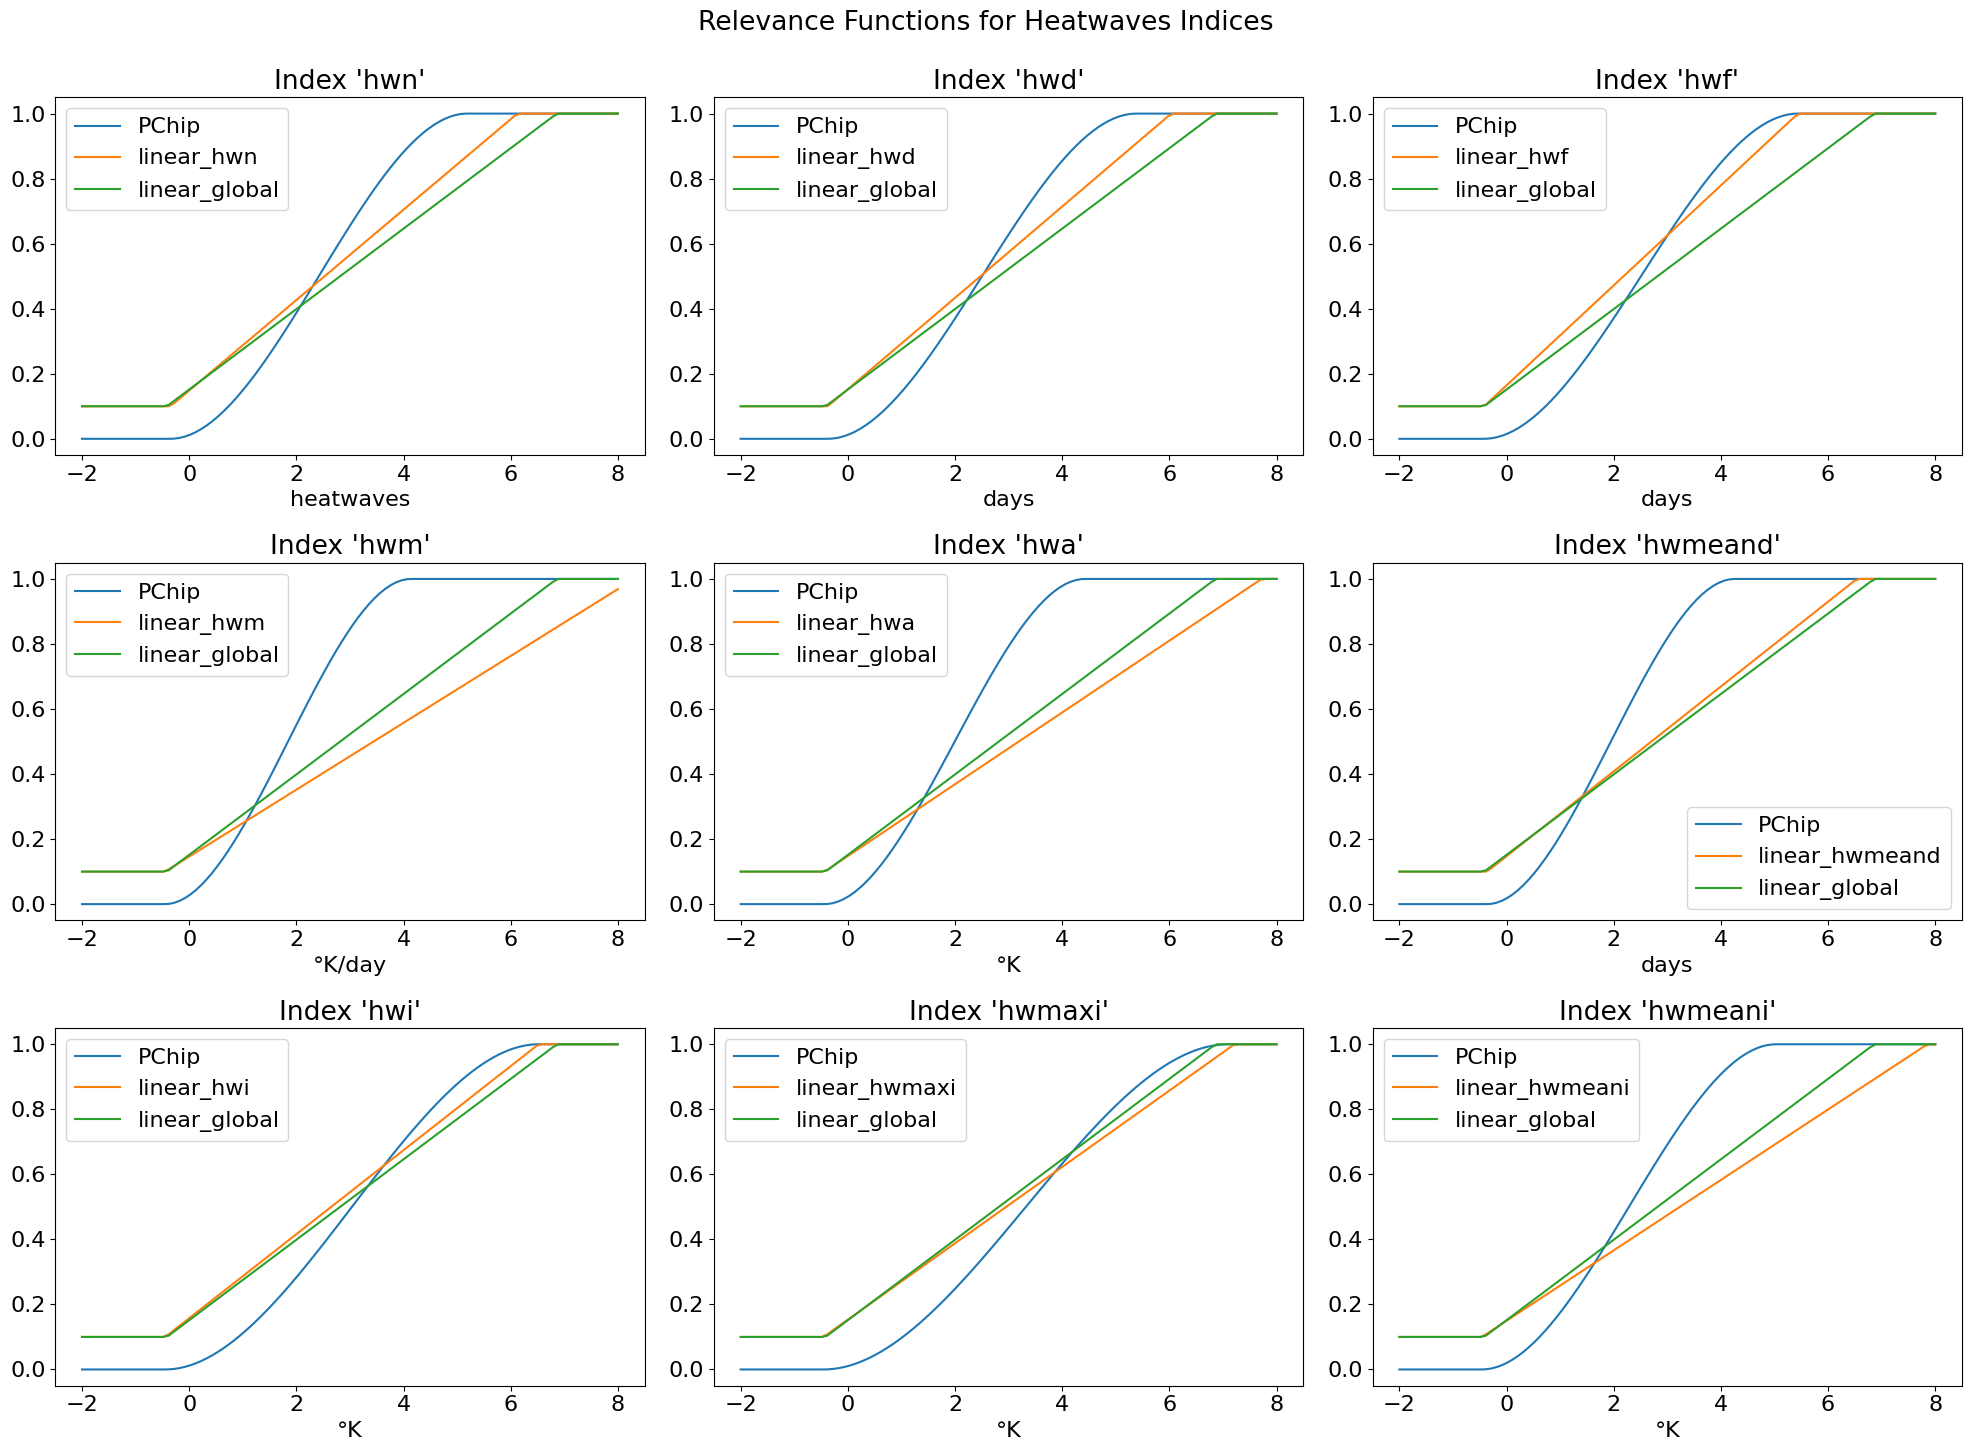

In [14]:
indices_of_interest =indices
print(indices_of_interest)
bounds = np.array((-1.1692892810242344, -0.30647585455315646, 3.0, 6.499969486244418))
print("Default bounds", bounds)

bounds_paper_list = []
x = np.linspace(-2, 8, 100)
fig, axs = plt.subplots(3, 3, figsize=(20,15))
axs = axs.flatten()
for i, index in enumerate(indices_of_interest):
    hws_index = hws_scaled_training[[index]].to_numpy()
    hws_index = hws_index.reshape(hws_index.shape[0])
    relevance = create_relevance_function(hws_index)
    l, m ,u  = compute_adjusted_boxplot_bounds(hws_index)
    bounds_paper = (l, m, u, max(hws_index))
    bounds_paper_list.append(bounds_paper)

    print(f"Index {index} paper bounds:", bounds_paper)
    f2 = piecewise_linear_phi_2(bounds_paper)
    f0 = piecewise_linear_phi_2(bounds)
    # x = np.linspace(np.min(hws_index), np.max(hws_index))
    axs[i].plot(x, relevance(x), label="PChip")
    axs[i].plot(x, f2(x), label=f"linear_{index}")
    # axs[i].plot(x, f0(x), label="default used")
    axs[i].set_title(f"Index '{index}'")
    axs[i].set_xlabel(units_hws[index])

bounds_avg = average_bounds(bounds_paper_list)

for i, index in enumerate(indices_of_interest):
    hws_index = hws_scaled_training[[index]].to_numpy()
    hws_index = hws_index.reshape(hws_index.shape[0])
    # x = np.linspace(np.min(hws_index), np.max(hws_index))
    axs[i].plot(x, piecewise_linear_phi_2(bounds_avg)(x), label="linear_global")
    axs[i].legend()
fig.suptitle("Relevance Functions for Heatwaves Indices")
fig.tight_layout(rect=[0, 0.01, 1, 0.99])
plt.show()

## SERA vs MAE

In [11]:
import tensorflow as tf
import os
import numpy as np
import random
import keras
import xarray as xr
import sys
import matplotlib.pyplot as plt
import pickle
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor


from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense, Dropout, GRU, Conv1D, Flatten, Reshape, Layer
from tensorflow.keras.callbacks import EarlyStopping


In [12]:
hws_chile = pd.read_csv("data/local_data/monthly/hws_chile_new_agg.csv")

hws_chile["time"] = pd.to_datetime(hws_chile["Unnamed: 0"],format='%Y-%m')
hws_chile.set_index('time', inplace=True)
hws_chile.drop(columns="Unnamed: 0", inplace=True)
indices = list(hws_chile.columns)
# hws_chile = hws_chile[["hwn", "hwf", "hwd", "hwm", "hwa", "hwmeani"]]
hws_chile

,hwn,hwf,hwd,hwm,hwa,hwmeand,hwi,hwmaxi,hwmeani
time,,,,,,,,,
1971-01-01,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
1971-02-01,0.2,0.7,0.7,0.447148,0.807169,0.7,1.508644,1.508644,1.508644
1971-03-01,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
1971-04-01,0.2,0.6,0.6,0.637038,0.982249,0.6,1.911113,1.911113,1.911113
1971-05-01,0.1,0.3,0.3,0.555671,0.901254,0.3,1.667013,1.667013,1.667013
...,...,...,...,...,...,...,...,...,...
2024-08-01,0.4,1.3,1.3,0.759857,1.294393,1.3,2.501609,2.501609,2.501609
2024-09-01,0.2,0.6,0.6,0.367076,0.617588,0.6,1.101228,1.101228,1.101228
2024-10-01,0.4,1.2,0.9,0.853280,1.349775,0.9,3.552305,2.792164,2.559840


In [13]:
with open("data/03_primary/drivers/era5_dict.pickle", 'rb') as handle:
    era5_v2 = pickle.load(handle)
era5_df = pd.concat((era5_v2["ERA5"],hws_chile),axis=1)
era5_df = era5_df[era5_df.index.year > 1970]
era5_df

,nino12,nino34,anom_wind_cl_raco,anom_wind_cl_puelche,anom_wind_pressure,anom_ta_cl,anom_pdo,anom_psl_sam_40,anom_psl_sam_65,anom_dmi_east,...,adv_chile,hwn,hwf,hwd,hwm,hwa,hwmeand,hwi,hwmaxi,hwmeani
time,,,,,,,,,,,,,,,,,,,,,
1971-01-01,-1.323449,-1.479654,0.004568,1.626114,-155.360306,-2.929806,-0.074776,-112.387703,341.377930,-0.536907,...,4.134146,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
1971-02-01,-1.141428,-1.604307,-0.288501,0.221068,-98.484497,-0.503788,-0.037966,57.690361,51.769032,-0.933078,...,0.214954,0.2,0.7,0.7,0.447148,0.807169,0.7,1.508644,1.508644,1.508644
1971-03-01,-1.170822,-1.821136,-0.237063,0.329253,-77.386848,-1.261046,-0.144552,6.743707,-146.034164,-0.957672,...,0.069712,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
1971-04-01,-0.556328,-1.182318,-0.485039,-0.753484,198.601791,-1.349036,-0.087349,-70.511070,233.869843,-0.813266,...,-1.091872,0.2,0.6,0.6,0.637038,0.982249,0.6,1.911113,1.911113,1.911113
1971-05-01,-1.159086,-1.029230,-0.084317,0.738629,185.134171,0.668153,-0.267097,-178.369583,701.905396,-0.772716,...,-0.240826,0.1,0.3,0.3,0.555671,0.901254,0.3,1.667013,1.667013,1.667013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-01,-0.107980,0.082571,-0.306670,-1.884179,452.930206,-1.053086,1.098336,-203.018234,536.929138,0.361525,...,-1.233973,0.4,1.3,1.3,0.759857,1.294393,1.3,2.501609,2.501609,2.501609
2024-09-01,-0.487674,-0.298912,0.694752,3.229236,-654.225525,-0.559750,1.172889,281.185516,-122.286896,0.537031,...,2.535206,0.2,0.6,0.6,0.367076,0.617588,0.6,1.101228,1.101228,1.101228
2024-10-01,-0.374066,-0.440446,-0.493092,-1.423323,114.399475,2.943502,1.171113,-6.615347,21.412451,0.930432,...,4.639970,0.4,1.2,0.9,0.853280,1.349775,0.9,3.552305,2.792164,2.559840


In [14]:
def average_bounds(list_bounds):
    result_bounds = []
    result_bounds.append(np.min([b[0] for b in list_bounds]))
    result_bounds.append(np.mean([b[1] for b in list_bounds]))
    result_bounds.append(np.mean([b[2] for b in list_bounds]))
    result_bounds.append(np.max([b[3] for b in list_bounds]))
    print("Result bounds", result_bounds)
    return result_bounds

In [15]:
## Data
features = list(era5_v2["ERA5"].columns)
labels = indices

X = era5_df[features]
y = era5_df[labels]

## Split
len_val = 5*12
len_test = 2*12

X_train, X_test, y_train, y_test = X[:-len_test], X[-len_test:], y[:-len_test], y[-len_test:]
X_train, X_val, y_train, y_val = X_train[:-len_val], X_train[-len_val:], y_train[:-len_val], y_train[-len_val:]

## Scaling
features_scaler = StandardScaler()
labels_scaler = StandardScaler()
X_train_scaled = features_scaler.fit_transform(X_train)
y_train_scaled = labels_scaler.fit_transform(y_train)
X_val_scaled = features_scaler.transform(X_val)
y_val_scaled = labels_scaler.transform(y_val)
X_test_scaled = features_scaler.transform(X_test)
y_test_scaled = labels_scaler.transform(y_test)


## SERA
bounds_paper_list = []
for i, label in enumerate(labels):
    y_train_label = y_train_scaled[:, i]
    # y_train_label = y_train_label.reshape(y_train_label.shape[0])
    l, m ,u  = compute_adjusted_boxplot_bounds(y_train_label)
    bounds_paper = (l, m, u, max(y_train_label))
    bounds_paper_list.append(bounds_paper)

bounds_avg = average_bounds(bounds_paper_list)
# bounds_avg = [-1.5366946087281974, -0.4163184421933129, 6.860691104388604, 7.339525422290547]
sera_loss = SERA(bounds=bounds_avg,T=100, initial_weight=0.1, fn="piecewise2")

class MultiLowerBoundLayer(Layer):
    def __init__(self, min_values, **kwargs):
        """
        min_values: array-like of shape (n_outputs,)
        """
        super().__init__(**kwargs)
        self.min_values = tf.constant(min_values, dtype=tf.float32)

    def call(self, inputs):
        return tf.maximum(inputs, self.min_values)

    def get_config(self):
        config = super().get_config()
        config.update({
            "min_values": self.min_values.numpy().tolist()
        })
        return config

## BOUNDS

min_bounds = y_train_scaled.min(axis=0)

rnn16_model = Sequential([
    SimpleRNN(16, activation="tanh", input_shape=(1, len(features))),
    Dropout(0.1),
    Dense(8, activation="relu"),
    Dense(len(labels)),
    MultiLowerBoundLayer(min_bounds)
])
lstm16_model = Sequential([
    LSTM(16, activation="tanh", input_shape=(1, len(features))),
    Dropout(0.1),  # Regularization
    Dense(8, activation="relu"),
    Dense(len(labels)),
    MultiLowerBoundLayer(min_bounds)
])
cnn_rnn_model = Sequential([
    Conv1D(16, kernel_size=1, activation="relu", input_shape=(1, len(features))),
    Reshape((1, 16)),  # Back to time dimension
    SimpleRNN(8, activation="tanh"),
    Dropout(0.1),
    Dense(len(labels)),
    MultiLowerBoundLayer(min_bounds)
])
lp_model = Sequential([
    Flatten(input_shape=(1, len(features))),
    Dense(16, activation="relu"),
    Dropout(0.1),
    Dense(8, activation="relu"),
    Dense(len(labels)),
    MultiLowerBoundLayer(min_bounds)
])
xgb_model = MultiOutputRegressor(XGBCustomObjective(
        objective_func=sera_objective(piecewise_linear_phi_np(bounds_avg, initial_weight=0.1)),
        n_estimators=15,
        learning_rate=0.1
    ))
models = {
    "RNN16" : rnn16_model,
    "LSTM16" : lstm16_model,
    "CNNRNN16": cnn_rnn_model,
    "MLP16": lp_model,
    "CXGB15" : xgb_model
}
models_results_sera = {model: {} for model in models.keys()}
models_predictions_sera = {model: {} for model in models.keys()}

for name, model in models.items():
    # Prediction dfs
    df_pred_train = pd.DataFrame(columns=labels, index=X_train.index)
    df_pred_val= pd.DataFrame(columns=labels, index=X_val.index)
    df_pred_test = pd.DataFrame(columns=labels, index=X_test.index)
    df_pred_train_unscaled = pd.DataFrame(columns=labels, index=X_train.index)
    df_pred_val_unscaled= pd.DataFrame(columns=labels, index=X_val.index)
    df_pred_test_unscaled = pd.DataFrame(columns=labels, index=X_test.index)

    for i in range(1,13):
        ## Data by season
        X_train_season, y_train_season = X_train[X_train.index.month==i], y_train[y_train.index.month==i] 
        X_val_season, y_val_season = X_val[X_val.index.month==i], y_val[y_val.index.month==i] 
        X_test_season, y_test_season = X_test[X_test.index.month==i], y_test[y_test.index.month==i] 

        ## Scale
        X_train_season_scaled = features_scaler.transform(X_train_season)
        y_train_season_scaled = labels_scaler.transform(y_train_season)
        X_val_season_scaled = features_scaler.transform(X_val_season)
        y_val_season_scaled = labels_scaler.transform(y_val_season)
        X_test_season_scaled = features_scaler.transform(X_test_season)
        y_test_season_scaled = labels_scaler.transform(y_test_season)

        ## Reshape for keras
        if "16" in name:
            X_train_season_keras = np.expand_dims(X_train_season_scaled, axis=1)
            X_val_season_keras = np.expand_dims(X_val_season_scaled, axis=1)
            X_test_season_keras = np.expand_dims(X_test_season_scaled, axis=1)

            # Clone model to reset weights for new season
            if i != 1:
                model = tf.keras.models.clone_model(model)

            # Compile
            model.compile(optimizer="adam", loss=sera_loss)

            # Training
            early_stopping = EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)
            model.fit(X_train_season_keras, y_train_season_scaled, epochs=200, batch_size=8, verbose=0, callbacks=[early_stopping], validation_data=(X_val_season_keras, y_val_season_scaled))
             # Prediction
            y_pred_train_season = model.predict(X_train_season_keras)
            y_pred_val_season = model.predict(X_val_season_keras)
            y_pred_test_season = model.predict(X_test_season_keras)
        else:
            model.fit(X_train_season_scaled, y_train_season_scaled)
            y_pred_train_season = model.predict(X_train_season_scaled)
            y_pred_val_season = model.predict(X_val_season_scaled)
            y_pred_test_season = model.predict(X_test_season_scaled)

        # Arrange in full span
        df_pred_train.loc[X_train_season.index] = y_pred_train_season
        df_pred_train.sort_index(inplace=True)
        df_pred_val.loc[X_val_season.index] = y_pred_val_season
        df_pred_val.sort_index(inplace=True)
        df_pred_test.loc[X_test_season.index] = y_pred_test_season
        df_pred_test.sort_index(inplace=True)
        df_pred_train_unscaled.loc[X_train_season.index] = labels_scaler.inverse_transform(y_pred_train_season)
        df_pred_train_unscaled.sort_index(inplace=True)
        df_pred_val_unscaled.loc[X_val_season.index] = labels_scaler.inverse_transform(y_pred_val_season)
        df_pred_val_unscaled.sort_index(inplace=True)
        df_pred_test_unscaled.loc[X_test_season.index] = labels_scaler.inverse_transform(y_pred_test_season)
        

    df_pred_train = df_pred_train.dropna()
    df_pred_train = df_pred_train.astype(np.number)

    df_pred_val = df_pred_val.dropna()
    df_pred_val = df_pred_val.astype(np.number)

    df_pred_test = df_pred_test.dropna()
    df_pred_test = df_pred_test.astype(np.number)

    df_pred_train_unscaled = df_pred_train_unscaled.dropna()
    df_pred_train_unscaled = df_pred_train_unscaled.astype(np.number)

    df_pred_val_unscaled = df_pred_val_unscaled.dropna()
    df_pred_val_unscaled = df_pred_val_unscaled.astype(np.number)

    df_pred_test_unscaled = df_pred_test_unscaled.dropna()
    df_pred_test_unscaled = df_pred_test_unscaled.astype(np.number)

    # Performance
    models_results_sera[name] = {
        "SERA_training" : np.array([sera_loss.call(y_train_scaled[:, i], df_pred_train[label]) for i,label in enumerate(labels)]),
        "SERA_val" : np.array([sera_loss.call(y_val_scaled[:, i], df_pred_val[label]) for i,label in enumerate(labels)]),
        "SERA_test" : np.array([sera_loss.call(y_test_scaled[:, i], df_pred_test[label]) for i,label in enumerate(labels)]),
        "mae_training": mean_absolute_error(y_train, df_pred_train_unscaled, multioutput="raw_values"),
        "mae_val": mean_absolute_error(y_val, df_pred_val_unscaled, multioutput="raw_values"),
        "mae_test": mean_absolute_error(y_test, df_pred_test_unscaled, multioutput="raw_values"),
        "mape_training": mean_absolute_percentage_error(y_train_scaled, df_pred_train, multioutput="raw_values"),
        "mape_val": mean_absolute_percentage_error(y_val_scaled, df_pred_val, multioutput="raw_values"),
        "mape_test": mean_absolute_percentage_error(y_test_scaled, df_pred_test, multioutput="raw_values"),
        "mse_training": mean_squared_error(y_train, df_pred_train_unscaled, multioutput="raw_values"),
        "mse_val": mean_squared_error(y_val, df_pred_val_unscaled, multioutput="raw_values"),
        "mse_test": mean_squared_error(y_test, df_pred_test_unscaled, multioutput="raw_values"),
    }
    models_predictions_sera[name] = {
        "pred_train" : df_pred_train,
        "pred_val" : df_pred_val,
        "pred_test" : df_pred_test,
        "pred_train_unscaled" : df_pred_train_unscaled,
        "pred_val_unscaled" : df_pred_val_unscaled,
        "pred_test_unscaled" : df_pred_test_unscaled,
    }

Result bounds [-1.5011122833746553, -0.36584072934073864, 7.120116294833575, 7.7937161476092776]
1/1 [==============================] - 0s 22ms/step


c:\Users\marti\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\dtypes\common.py:1687: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  npdtype = np.dtype(dtype)
c:\Users\marti\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\dtypes\common.py:1687: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  npdtype = np.dtype(dtype)
c:\Users\marti\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\dtypes\common.py:1687: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  npdtype = np.dtype(dtype)
c:\Users\marti\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\dtypes\common.py:1687: DeprecationWarning: Converting `np

1/1 [==============================] - 0s 24ms/step


c:\Users\marti\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\dtypes\common.py:1687: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  npdtype = np.dtype(dtype)
c:\Users\marti\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\dtypes\common.py:1687: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  npdtype = np.dtype(dtype)
c:\Users\marti\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\dtypes\common.py:1687: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  npdtype = np.dtype(dtype)
c:\Users\marti\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\dtypes\common.py:1687: DeprecationWarning: Converting `np

1/1 [==============================] - 0s 28ms/step


c:\Users\marti\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\dtypes\common.py:1687: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  npdtype = np.dtype(dtype)
c:\Users\marti\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\dtypes\common.py:1687: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  npdtype = np.dtype(dtype)
c:\Users\marti\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\dtypes\common.py:1687: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  npdtype = np.dtype(dtype)
c:\Users\marti\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\dtypes\common.py:1687: DeprecationWarning: Converting `np

1/1 [==============================] - 0s 25ms/step


c:\Users\marti\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\dtypes\common.py:1687: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  npdtype = np.dtype(dtype)
c:\Users\marti\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\dtypes\common.py:1687: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  npdtype = np.dtype(dtype)
c:\Users\marti\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\dtypes\common.py:1687: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  npdtype = np.dtype(dtype)
c:\Users\marti\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\dtypes\common.py:1687: DeprecationWarning: Converting `np

In [19]:
## Data
features = list(era5_v2["ERA5"].columns)
labels = indices

X = era5_df[features]
y = era5_df[labels]

## Split
len_val = 5*12
len_test = 2*12

X_train, X_test, y_train, y_test = X[:-len_test], X[-len_test:], y[:-len_test], y[-len_test:]
X_train, X_val, y_train, y_val = X_train[:-len_val], X_train[-len_val:], y_train[:-len_val], y_train[-len_val:]

## Scaling
features_scaler = StandardScaler()
labels_scaler = StandardScaler()
X_train_scaled = features_scaler.fit_transform(X_train)
y_train_scaled = labels_scaler.fit_transform(y_train)
X_val_scaled = features_scaler.transform(X_val)
y_val_scaled = labels_scaler.transform(y_val)
X_test_scaled = features_scaler.transform(X_test)
y_test_scaled = labels_scaler.transform(y_test)


## SERA
bounds_paper_list = []
for i, label in enumerate(labels):
    y_train_label = y_train_scaled[:, i]
    # y_train_label = y_train_label.reshape(y_train_label.shape[0])
    l, m ,u  = compute_adjusted_boxplot_bounds(y_train_label)
    bounds_paper = (l, m, u, max(y_train_label))
    bounds_paper_list.append(bounds_paper)

bounds_avg = average_bounds(bounds_paper_list)
# bounds_avg = [-1.5366946087281974, -0.4163184421933129, 6.860691104388604, 7.339525422290547]
sera_loss = SERA(bounds=bounds_avg,T=100, initial_weight=0.1, fn="piecewise2")

class MultiLowerBoundLayer(Layer):
    def __init__(self, min_values, **kwargs):
        """
        min_values: array-like of shape (n_outputs,)
        """
        super().__init__(**kwargs)
        self.min_values = tf.constant(min_values, dtype=tf.float32)

    def call(self, inputs):
        return tf.maximum(inputs, self.min_values)

    def get_config(self):
        config = super().get_config()
        config.update({
            "min_values": self.min_values.numpy().tolist()
        })
        return config

## BOUNDS

min_bounds = y_train_scaled.min(axis=0)

rnn16_model = Sequential([
    SimpleRNN(16, activation="tanh", input_shape=(1, len(features))),
    Dropout(0.1),
    Dense(8, activation="relu"),
    Dense(len(labels)),
    MultiLowerBoundLayer(min_bounds)
])
lstm16_model = Sequential([
    LSTM(16, activation="tanh", input_shape=(1, len(features))),
    Dropout(0.1),  # Regularization
    Dense(8, activation="relu"),
    Dense(len(labels)),
    MultiLowerBoundLayer(min_bounds)
])
cnn_rnn_model = Sequential([
    Conv1D(16, kernel_size=1, activation="relu", input_shape=(1, len(features))),
    Reshape((1, 16)),  # Back to time dimension
    SimpleRNN(8, activation="tanh"),
    Dropout(0.1),
    Dense(len(labels)),
    MultiLowerBoundLayer(min_bounds)
])
lp_model = Sequential([
    Flatten(input_shape=(1, len(features))),
    Dense(16, activation="relu"),
    Dropout(0.1),
    Dense(8, activation="relu"),
    Dense(len(labels)),
    MultiLowerBoundLayer(min_bounds)
])
xgb_model = MultiOutputRegressor(XGBCustomObjective(
        # objective_func=sera_objective(piecewise_linear_phi_np(bounds_avg, initial_weight=0.1)),
        n_estimators=15,
        learning_rate=0.1
    ))
models = {
    "RNN16" : rnn16_model,
    "LSTM16" : lstm16_model,
    "CNNRNN16": cnn_rnn_model,
    "MLP16": lp_model,
    "CXGB15" : xgb_model
}
models_results_mae = {model: {} for model in models.keys()}
models_predictions_mae = {model: {} for model in models.keys()}

for name, model in models.items():
    # Prediction dfs
    df_pred_train = pd.DataFrame(columns=labels, index=X_train.index)
    df_pred_val= pd.DataFrame(columns=labels, index=X_val.index)
    df_pred_test = pd.DataFrame(columns=labels, index=X_test.index)
    df_pred_train_unscaled = pd.DataFrame(columns=labels, index=X_train.index)
    df_pred_val_unscaled= pd.DataFrame(columns=labels, index=X_val.index)
    df_pred_test_unscaled = pd.DataFrame(columns=labels, index=X_test.index)

    for i in range(1,13):
        ## Data by season
        X_train_season, y_train_season = X_train[X_train.index.month==i], y_train[y_train.index.month==i] 
        X_val_season, y_val_season = X_val[X_val.index.month==i], y_val[y_val.index.month==i] 
        X_test_season, y_test_season = X_test[X_test.index.month==i], y_test[y_test.index.month==i] 

        ## Scale
        X_train_season_scaled = features_scaler.transform(X_train_season)
        y_train_season_scaled = labels_scaler.transform(y_train_season)
        X_val_season_scaled = features_scaler.transform(X_val_season)
        y_val_season_scaled = labels_scaler.transform(y_val_season)
        X_test_season_scaled = features_scaler.transform(X_test_season)
        y_test_season_scaled = labels_scaler.transform(y_test_season)

        ## Reshape for keras
        if "16" in name:
            X_train_season_keras = np.expand_dims(X_train_season_scaled, axis=1)
            X_val_season_keras = np.expand_dims(X_val_season_scaled, axis=1)
            X_test_season_keras = np.expand_dims(X_test_season_scaled, axis=1)

            # Clone model to reset weights for new season
            if i != 1:
                model = tf.keras.models.clone_model(model)

            # Compile
            model.compile(optimizer="adam", loss="mae")

            # Training
            early_stopping = EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)
            model.fit(X_train_season_keras, y_train_season_scaled, epochs=200, batch_size=8, verbose=0, callbacks=[early_stopping], validation_data=(X_val_season_keras, y_val_season_scaled))
             # Prediction
            y_pred_train_season = model.predict(X_train_season_keras)
            y_pred_val_season = model.predict(X_val_season_keras)
            y_pred_test_season = model.predict(X_test_season_keras)
        else:
            model.fit(X_train_season_scaled, y_train_season_scaled)
            y_pred_train_season = model.predict(X_train_season_scaled)
            y_pred_val_season = model.predict(X_val_season_scaled)
            y_pred_test_season = model.predict(X_test_season_scaled)

        # Arrange in full span
        df_pred_train.loc[X_train_season.index] = y_pred_train_season
        df_pred_train.sort_index(inplace=True)
        df_pred_val.loc[X_val_season.index] = y_pred_val_season
        df_pred_val.sort_index(inplace=True)
        df_pred_test.loc[X_test_season.index] = y_pred_test_season
        df_pred_test.sort_index(inplace=True)
        df_pred_train_unscaled.loc[X_train_season.index] = labels_scaler.inverse_transform(y_pred_train_season)
        df_pred_train_unscaled.sort_index(inplace=True)
        df_pred_val_unscaled.loc[X_val_season.index] = labels_scaler.inverse_transform(y_pred_val_season)
        df_pred_val_unscaled.sort_index(inplace=True)
        df_pred_test_unscaled.loc[X_test_season.index] = labels_scaler.inverse_transform(y_pred_test_season)
        

    df_pred_train = df_pred_train.dropna()
    df_pred_train = df_pred_train.astype(np.number)

    df_pred_val = df_pred_val.dropna()
    df_pred_val = df_pred_val.astype(np.number)

    df_pred_test = df_pred_test.dropna()
    df_pred_test = df_pred_test.astype(np.number)

    df_pred_train_unscaled = df_pred_train_unscaled.dropna()
    df_pred_train_unscaled = df_pred_train_unscaled.astype(np.number)

    df_pred_val_unscaled = df_pred_val_unscaled.dropna()
    df_pred_val_unscaled = df_pred_val_unscaled.astype(np.number)

    df_pred_test_unscaled = df_pred_test_unscaled.dropna()
    df_pred_test_unscaled = df_pred_test_unscaled.astype(np.number)

    # Performance
    models_results_mae[name] = {
        "SERA_training" : np.array([sera_loss.call(y_train_scaled[:, i], df_pred_train[label]) for i,label in enumerate(labels)]),
        "SERA_val" : np.array([sera_loss.call(y_val_scaled[:, i], df_pred_val[label]) for i,label in enumerate(labels)]),
        "SERA_test" : np.array([sera_loss.call(y_test_scaled[:, i], df_pred_test[label]) for i,label in enumerate(labels)]),
        "mae_training": mean_absolute_error(y_train, df_pred_train_unscaled, multioutput="raw_values"),
        "mae_val": mean_absolute_error(y_val, df_pred_val_unscaled, multioutput="raw_values"),
        "mae_test": mean_absolute_error(y_test, df_pred_test_unscaled, multioutput="raw_values"),
        "mape_training": mean_absolute_percentage_error(y_train_scaled, df_pred_train, multioutput="raw_values"),
        "mape_val": mean_absolute_percentage_error(y_val_scaled, df_pred_val, multioutput="raw_values"),
        "mape_test": mean_absolute_percentage_error(y_test_scaled, df_pred_test, multioutput="raw_values"),
        "mse_training": mean_squared_error(y_train, df_pred_train_unscaled, multioutput="raw_values"),
        "mse_val": mean_squared_error(y_val, df_pred_val_unscaled, multioutput="raw_values"),
        "mse_test": mean_squared_error(y_test, df_pred_test_unscaled, multioutput="raw_values"),
    }
    models_predictions_mae[name] = {
        "pred_train" : df_pred_train,
        "pred_val" : df_pred_val,
        "pred_test" : df_pred_test,
        "pred_train_unscaled" : df_pred_train_unscaled,
        "pred_val_unscaled" : df_pred_val_unscaled,
        "pred_test_unscaled" : df_pred_test_unscaled,
    }

Result bounds [-1.5011122833746553, -0.36584072934073864, 7.120116294833575, 7.7937161476092776]
1/1 [==============================] - 0s 23ms/step


c:\Users\marti\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\dtypes\common.py:1687: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  npdtype = np.dtype(dtype)
c:\Users\marti\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\dtypes\common.py:1687: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  npdtype = np.dtype(dtype)
c:\Users\marti\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\dtypes\common.py:1687: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  npdtype = np.dtype(dtype)
c:\Users\marti\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\dtypes\common.py:1687: DeprecationWarning: Converting `np

1/1 [==============================] - 0s 24ms/step


c:\Users\marti\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\dtypes\common.py:1687: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  npdtype = np.dtype(dtype)
c:\Users\marti\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\dtypes\common.py:1687: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  npdtype = np.dtype(dtype)
c:\Users\marti\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\dtypes\common.py:1687: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  npdtype = np.dtype(dtype)
c:\Users\marti\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\dtypes\common.py:1687: DeprecationWarning: Converting `np

1/1 [==============================] - 0s 23ms/step


c:\Users\marti\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\dtypes\common.py:1687: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  npdtype = np.dtype(dtype)
c:\Users\marti\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\dtypes\common.py:1687: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  npdtype = np.dtype(dtype)
c:\Users\marti\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\dtypes\common.py:1687: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  npdtype = np.dtype(dtype)
c:\Users\marti\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\dtypes\common.py:1687: DeprecationWarning: Converting `np

1/1 [==============================] - 0s 23ms/step


c:\Users\marti\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\dtypes\common.py:1687: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  npdtype = np.dtype(dtype)
c:\Users\marti\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\dtypes\common.py:1687: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  npdtype = np.dtype(dtype)
c:\Users\marti\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\dtypes\common.py:1687: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  npdtype = np.dtype(dtype)
c:\Users\marti\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\dtypes\common.py:1687: DeprecationWarning: Converting `np

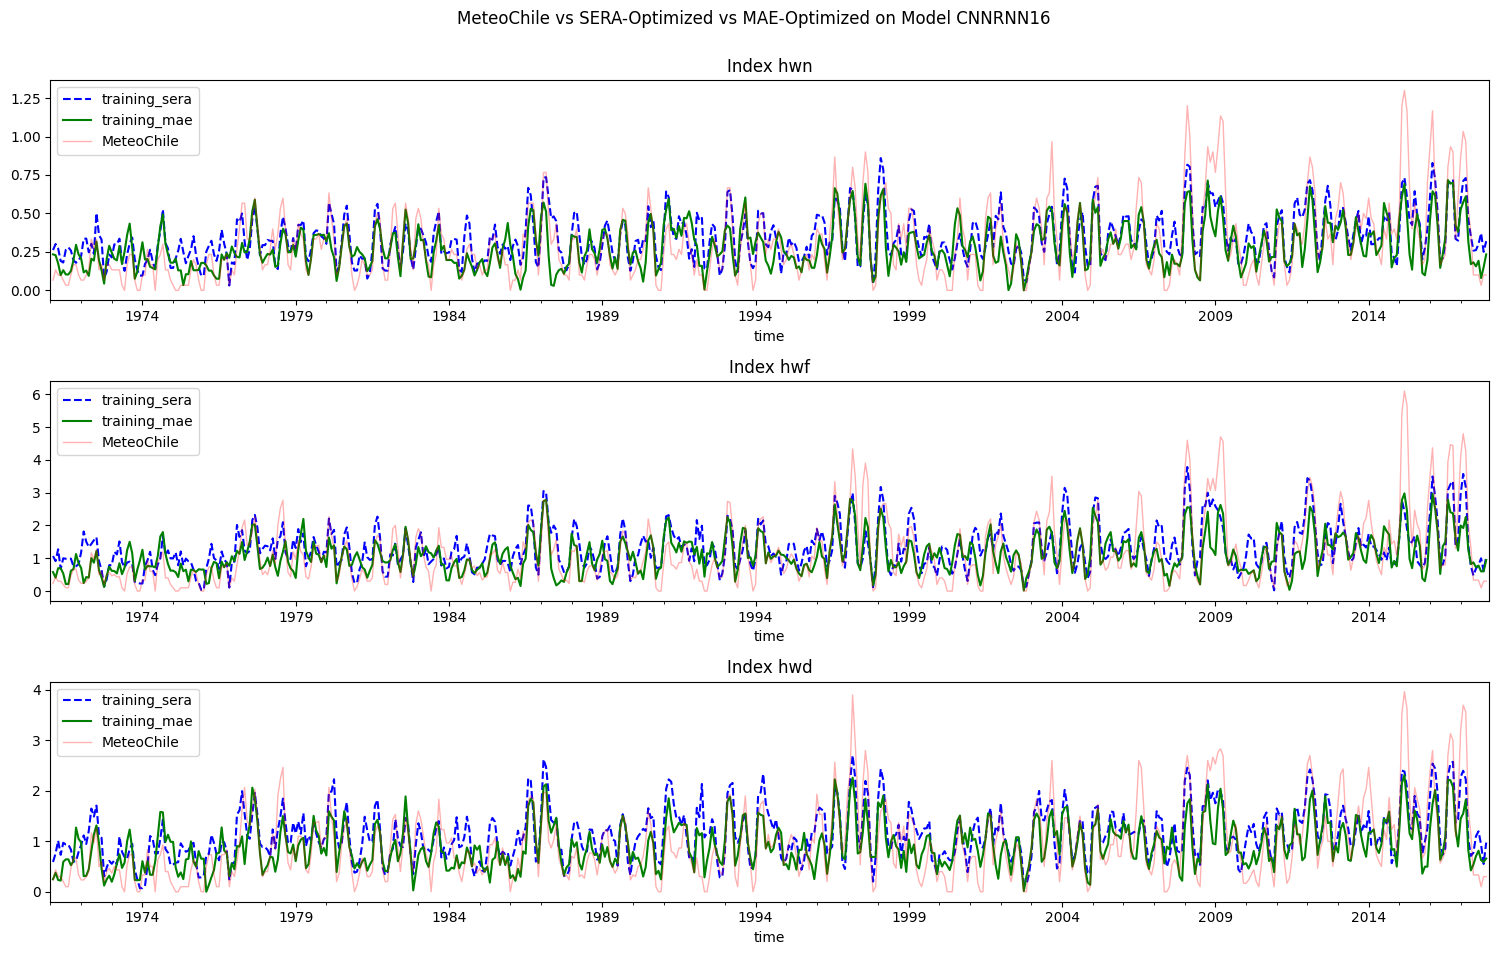

In [48]:
# df_pred_train_yearly = transform_time_label(df_pred_train_unscaled, "year")
# df_pred_val_yearly = transform_time_label(df_pred_val_unscaled, "year")
# df_pred_test_yearly = transform_time_label(df_pred_test_unscaled, "year")
# meteochile_yearly = transform_time_label(hws_chile, "year")
model = "CNNRNN16"
hws_chile = hws_chile[hws_chile.index.year < 2018]
fig, axs = plt.subplots(len(labels[:3]), figsize=(15, 10))
for i, index in enumerate(labels[:3]):
    models_predictions_sera[model]["pred_train_unscaled"].rolling(3, center=True).mean().plot(y=index, ax=axs[i], label="training_sera", color="blue", linestyle="dashed")
    # models_predictions_sera[model]["pred_val_unscaled"].rolling(3, center=True).mean().plot(y=index, ax=axs[i], label="val", color="orange")
    # models_predictions_sera[model]["pred_test_unscaled"].rolling(3, center=True).mean().plot(y=index, ax=axs[i], label="test", color="green")
    models_predictions_mae[model]["pred_train_unscaled"].rolling(3, center=True).mean().plot(y=index, ax=axs[i], label="training_mae", color="green")
    # models_predictions_mae[model]["pred_val_unscaled"].rolling(3, center=True).mean().plot(y=index, ax=axs[i], label="val", color="orange", linestyle="dashed")
    # models_predictions_mae[model]["pred_test_unscaled"].rolling(3, center=True).mean().plot(y=index, ax=axs[i], label="test", color="green", linestyle="dashed")
    hws_chile.rolling(3, center=True).mean().plot(y=index, ax=axs[i], label="MeteoChile", alpha=0.3, lw=1, color="red") #alpha or linewidth
    axs[i].set_title(f"Index {index}")
fig.suptitle(f"MeteoChile vs SERA-Optimized vs MAE-Optimized on Model {model}")
fig.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

In [23]:
models_results_sera["LSTM16"]

{'SERA_training': array([ 71.96807 ,  74.432846,  75.34922 , 102.79045 ,  99.07177 ,
         72.95477 , 115.1162  , 121.31589 , 110.2336  ], dtype=float32),
 'SERA_val': array([13.2779045, 10.289433 ,  9.936023 , 14.910768 , 16.123713 ,
         9.551154 , 17.32562  , 11.812774 , 13.019732 ], dtype=float32),
 'SERA_test': array([ 8.345727 , 13.140789 , 12.231614 ,  9.599056 ,  7.564226 ,
        13.924315 , 15.028818 , 14.368133 , 15.7069435], dtype=float32),
 'mae_training': array([0.19686203, 0.76684636, 0.61811007, 0.35174481, 0.65034948,
        0.5820475 , 1.91829387, 1.55361685, 1.41461043]),
 'mae_val': array([0.20735277, 0.8900034 , 0.7126595 , 0.44539048, 0.74932856,
        0.63515106, 2.33000167, 1.81757588, 1.69428017]),
 'mae_test': array([0.32953776, 1.5209972 , 1.20624398, 0.53828412, 0.96911305,
        1.11858429, 3.42952169, 2.96200794, 2.33699465]),
 'mape_training': array([3.33182907, 1.37058243, 1.44484497, 1.18887401, 2.94718144,
        3.07881876, 1.34307086, 8

In [24]:
models_results_mae["LSTM16"]

{'SERA_training': array([100.310394, 154.54971 , 105.297966, 106.69269 ,  90.27732 ,
        127.77591 , 125.92483 , 126.31906 ,  88.98113 ], dtype=float32),
 'SERA_val': array([17.778397, 20.05533 , 12.980687, 17.913963, 16.029547, 18.599422,
        22.706846, 15.487837, 17.060097], dtype=float32),
 'SERA_test': array([11.041527, 21.512602, 16.605938, 11.081568,  9.218533, 17.539444,
        13.754024, 15.26489 , 16.528944], dtype=float32),
 'mae_training': array([0.17637848, 0.76131908, 0.59312501, 0.3106906 , 0.54093756,
        0.56964934, 1.59684659, 1.25974136, 1.14226256]),
 'mae_val': array([0.21623663, 0.87576159, 0.66594898, 0.37287692, 0.70434474,
        0.65464177, 2.40072581, 1.70505697, 1.63784994]),
 'mae_test': array([0.28706591, 1.43009819, 0.98285117, 0.40415593, 0.75692422,
        0.90722013, 3.00674563, 2.40859765, 2.21794091]),
 'mape_training': array([2.02851284, 1.00409778, 0.95314445, 1.06369645, 1.26959446,
        1.30968397, 0.9893551 , 6.5800853 , 0.91396

In [52]:
df_test = pd.DataFrame( columns=["SERA", "MAE", "MSE"])
for name, results in models_results_sera.items():
    df_test.loc[f"{name}_SERA"] = np.mean(results["SERA_test"]), np.mean(results["mae_test"]), np.mean(results["mse_test"])
for name, results in models_results_mae.items():
    df_test.loc[f"{name}_MAE"] = np.mean(results["SERA_test"]), np.mean(results["mae_test"]), np.mean(results["mse_test"])
display(
    df_test.sort_index()
    .style.set_caption("Performance Metrics on Test Set by model")
    .format({"SERA":"{:.2f}", "MAE":"{:.2f}","MSE":"{:.2f}"})
)

,SERA,MAE,MSE
CNNRNN16_MAE,16.95,1.56,6.42
CNNRNN16_SERA,12.71,1.62,5.70
CXGB15_MAE,15.45,1.39,6.00
CXGB15_SERA,11.33,1.45,5.41
LSTM16_MAE,14.73,1.38,5.55
LSTM16_SERA,12.21,1.60,6.20
MLP16_MAE,17.26,1.52,6.29
MLP16_SERA,13.57,1.66,6.66
RNN16_MAE,14.66,1.43,5.57
RNN16_SERA,13.95,1.52,6.43


In [54]:
latex_str = df_test.sort_index().to_latex(formatters={"SERA":"{:.2f}", "MAE":"{:.2f}","MSE":"{:.2f}","max":"{:.2f}", "out_2std":"{:.1%}"},caption="Performance Metrics on Test Set by model", label="tab:mae_vs_sera")
print(latex_str)

\begin{table}
\caption{Performance Metrics on Test Set by model}
\label{tab:mae_vs_sera}
\begin{tabular}{lrrr}
\toprule
 & SERA & MAE & MSE \\
\midrule
CNNRNN16_MAE & 16.95 & 1.56 & 6.42 \\
CNNRNN16_SERA & 12.71 & 1.62 & 5.70 \\
CXGB15_MAE & 15.45 & 1.39 & 6.00 \\
CXGB15_SERA & 11.33 & 1.45 & 5.41 \\
LSTM16_MAE & 14.73 & 1.38 & 5.55 \\
LSTM16_SERA & 12.21 & 1.60 & 6.20 \\
MLP16_MAE & 17.26 & 1.52 & 6.29 \\
MLP16_SERA & 13.57 & 1.66 & 6.66 \\
RNN16_MAE & 14.66 & 1.43 & 5.57 \\
RNN16_SERA & 13.95 & 1.52 & 6.43 \\
\bottomrule
\end{tabular}
\end{table}

